# Fair Credit Scoring — Home Credit (v7: Threshold Calibration + EqOddsPostprocessing)

Iteration on **Kozodoi, Jacob & Lessmann (2022)**, *EJOR 297(3): 1083–1094*.

**What changed from v6 → v7**

**Root-cause diagnosis from v6:**
- EOD_baseline (Age) = 0.3193 — Young group has TPR=25.6% vs Old 57.5%
- EG-EO sweep failed at ALL eps: EOD stuck ~0.21-0.22, AUC drop ~9% (5 predictors, premature convergence due to young group = only 3.97% of data)
- EG-DP made bias WORSE (EOD=0.64)
- Counterfactual fairness of Age ≈ 0 (Mean |Δscore|=0.0006) → bias is via proxies, not direct

**HIGH-RISK proxies identified:** `DAYS_BIRTH`, `BURO_DAYS_CREDIT_MIN`, `EXT_SOURCE_1`

**Three targeted strategies in v7:**

| # | Strategy | Type | Target |
|---|----------|------|--------|
| 1 | **Per-group Threshold Calibration** | Post-processing | Equalize TPR across Young/Old |
| 2 | **AIF360 EqOddsPostprocessing** | Post-processing | Equalize TPR+FPR via score remixing |

**Unchanged from v6**
- LightGBM with 5-fold stratified CV
- Sensitive attribute: age group (threshold = 25, per Kamiran & Calders 2009)
- Metrics: Profit (Verbraken et al. 2014), AUC, IND, SP, SF
- All auxiliary tables: bureau, bureau_balance, previous_application, installments_payments
- Full audit pipeline

**Data**: download from <https://www.kaggle.com/competitions/home-credit-default-risk/data> into `./data/`.

**Install**:
```bash
pip install pandas numpy scikit-learn lightgbm matplotlib seaborn aif360 fairlearn shap
```


## Install libs

In [1]:
!pip install aif360 lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 4.8 MB/s eta 0:00:00


In [2]:
!pip install BlackBoxAuditing -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
!pip install pandas numpy scikit-learn lightgbm matplotlib seaborn aif360 'tensorflow<2.16'

ERROR: Could not find a version that satisfies the requirement tensorflow<2.16 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow<2.16


## 1. Imports & Configuration

### 1.1 Standard libraries

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Modelling stack

In [5]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
import lightgbm as lgb

### 1.3 Fairness library (AIF360)

In [6]:
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing, DisparateImpactRemover
from aif360.algorithms.postprocessing import RejectOptionClassification, EqOddsPostprocessing

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


### 1.4 Constants

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
DATA = '/content/drive/MyDrive/pattern_project/'

In [9]:
SEED = 42
AGE_THRESHOLD = 25  # Kamiran & Calders (2009)
np.random.seed(SEED)

## 2. Data Prep

### 2.1 Read the file

In [10]:
df = pd.read_csv(DATA + 'application_train.csv')
print(f'Shape: {df.shape}')
print(f'Default rate: {df.TARGET.mean():.4f}')
df.head()

Shape: (307511, 122)
Default rate: 0.0807


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.2 Drop unknown gender (Koehrsen-style cleanup)

In [11]:
df = df[df['CODE_GENDER'] != 'XNA'].reset_index(drop=True)
print(f'After removing XNA gender: {df.shape}')

After removing XNA gender: (307507, 122)


### 2.3 Handle the `DAYS_EMPLOYED` anomaly

Some rows have `DAYS_EMPLOYED = 365243` (~1000 years). Replace with NaN.

In [12]:
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

### 2.4 Hand-crafted ratio features

In [13]:
df['DAYS_EMPLOYED_PERC']   = df['DAYS_EMPLOYED']    / df['DAYS_BIRTH']
df['INCOME_CREDIT_PERC']   = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['ANNUITY_INCOME_PERC']  = df['AMT_ANNUITY']      / df['AMT_INCOME_TOTAL']
df['PAYMENT_RATE']         = df['AMT_ANNUITY']      / df['AMT_CREDIT']

## 2.5b Auxiliary tables (v5 upgrade)

v4 used **only `application_train.csv`**. The model leaned heavily on `EXT_SOURCE_3`,
which the audit identified as the main bias channel against young applicants
(young people have shorter credit histories → worse external scores → systematically
penalised by the model even before we look at default behaviour).

**v5 brings in four auxiliary tables** from the Home Credit Default Risk competition:

| Table | What it contains | What we extract |
|---|---|---|
| `bureau.csv` | Loans the applicant has at *other* credit institutions (per Credit Bureau) | counts, totals, overdue amounts, max DPD, credit-type mix |
| `bureau_balance.csv` | Monthly status of each bureau loan | share of months with DPD, status mix |
| `previous_application.csv` | The applicant's previous applications at Home Credit | approval rate, avg credit / annuity, contract-type mix |
| `installments_payments.csv` | Payment history on previous Home Credit loans | days-past-due stats, payment-vs-installment ratio |

For each table we one-hot encode the categoricals **before** aggregation, then
groupby `SK_ID_CURR` and take mean / sum / max / min / count where appropriate.
The result: ~few hundred extra numeric features keyed on `SK_ID_CURR` that we
left-join onto the application table. (Final feature count typically jumps
from ~245 to ~700+.)

> **Why this should reduce EXT_SOURCE_3 reliance:** young applicants who have a
> *clean* installment-payment record or a *short-but-clean* bureau history will
> now get credit for that signal directly, instead of being judged purely on a
> bureau-score that already encodes their age disadvantage.

> **What to watch in the audit (re-run after this):** in v4, `EXT_SOURCE_3` was
> the #1 SHAP feature and the dominant proxy. After v5 you should see (a) its
> SHAP importance drop relative to several `INSTAL_*` and `BURO_*` features,
> and (b) the per-group EOD/DPD metrics for the young-vs-old split shrink.
> If they don't shrink, that's also a finding — it means the bias is structural
> in the data and we need a fairness post-processor (Section 6+ already covers
> these), not just more features.


In [14]:
# ---- Helper: one-hot encode aux table, then aggregate by SK_ID_CURR ----
# Pattern adapted from the well-known Home Credit Kaggle solutions
# (Aguiar 2018; Koehrsen 2018). Categorical columns are turned into 0/1
# indicators *before* groupby so that aggregations stay purely numeric.

def one_hot_encoder(frame, nan_as_category=True):
    """One-hot encode object columns in-place; return (frame, new_columns)."""
    original_cols = list(frame.columns)
    cat_cols = [c for c in frame.columns if frame[c].dtype == 'object']
    frame = pd.get_dummies(frame, columns=cat_cols, dummy_na=nan_as_category)
    new_cols = [c for c in frame.columns if c not in original_cols]
    return frame, new_cols

def agg_numeric(frame, group_var, df_name, num_aggs=('mean', 'max', 'min', 'sum')):
    """Group `frame` by `group_var` and aggregate every numeric column.
    Skip the id columns themselves so we don't aggregate ids."""
    for col in frame:
        if col != group_var and 'SK_ID' in col:
            frame = frame.drop(columns=col)
    numeric_df = frame.select_dtypes('number')
    numeric_df[group_var] = frame[group_var]
    agg = numeric_df.groupby(group_var).agg(list(num_aggs))
    # flatten MultiIndex column names: ('AMT_CREDIT_SUM', 'mean') -> 'BUREAU_AMT_CREDIT_SUM_MEAN'
    agg.columns = [f'{df_name}_{c[0]}_{c[1].upper()}' for c in agg.columns]
    return agg.reset_index()

print('Helper functions defined: one_hot_encoder, agg_numeric')


Helper functions defined: one_hot_encoder, agg_numeric


### 2.5b.1 Bureau + bureau_balance

In [15]:
# ---- bureau.csv  +  bureau_balance.csv ----
# bureau:         one row per external loan the applicant has (or had)
# bureau_balance: one row per (bureau loan, month) with status (0..5, C, X)

bureau         = pd.read_csv(DATA + 'bureau.csv')
bureau_balance = pd.read_csv(DATA + 'bureau_balance.csv')
print(f'bureau:         {bureau.shape}')
print(f'bureau_balance: {bureau_balance.shape}')

# --- bureau_balance: aggregate to one row per bureau loan (SK_ID_BUREAU) ---
bb, bb_cat = one_hot_encoder(bureau_balance, nan_as_category=False)
# numeric: MONTHS_BALANCE  (how recent / how long the history)
# categorical: STATUS (now one-hot)
bb_aggs = {'MONTHS_BALANCE': ['min', 'max', 'size']}
for c in bb_cat:
    bb_aggs[c] = ['mean']
bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggs)
bb_agg.columns = [f'{c[0]}_{c[1].upper()}' for c in bb_agg.columns]

# --- merge bureau_balance summary onto bureau, then aggregate to SK_ID_CURR ---
bureau = bureau.join(bb_agg, on='SK_ID_BUREAU', how='left')
bureau = bureau.drop(columns=['SK_ID_BUREAU'])
bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=False)

# numeric aggregations
num_aggs = {
    'DAYS_CREDIT':           ['min', 'max', 'mean'],
    'DAYS_CREDIT_ENDDATE':   ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE':    ['mean'],
    'CREDIT_DAY_OVERDUE':    ['max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE':['mean'],
    'AMT_CREDIT_SUM':        ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT':   ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE':['mean'],
    'AMT_CREDIT_SUM_LIMIT':  ['mean', 'sum'],
    'AMT_ANNUITY':           ['max', 'mean'],
    'CNT_CREDIT_PROLONG':    ['sum'],
    'MONTHS_BALANCE_MIN':    ['min'],
    'MONTHS_BALANCE_MAX':    ['max'],
    'MONTHS_BALANCE_SIZE':   ['mean', 'sum'],
}
# add 'mean' over each one-hot column from both bureau categoricals and bureau_balance categoricals
cat_aggs = {c: ['mean'] for c in bureau_cat}
for c in bb_cat:
    col = f'{c}_MEAN'
    if col in bureau.columns:
        cat_aggs[col] = ['mean']

bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggs, **cat_aggs})
bureau_agg.columns = [f'BURO_{c[0]}_{c[1].upper()}' for c in bureau_agg.columns]

# count of bureau loans per applicant (very predictive)
bureau_agg['BURO_COUNT'] = bureau.groupby('SK_ID_CURR').size()

# split active vs closed for richer signal
active = bureau[bureau.get('CREDIT_ACTIVE_Active', 0) == 1] if 'CREDIT_ACTIVE_Active' in bureau.columns else None
if active is not None and len(active) > 0:
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggs)
    active_agg.columns = [f'BURO_ACTIVE_{c[0]}_{c[1].upper()}' for c in active_agg.columns]
    bureau_agg = bureau_agg.join(active_agg, how='left')

print(f'bureau_agg: {bureau_agg.shape}')
del bureau, bureau_balance, bb, bb_agg


bureau:         (1716428, 17)
bureau_balance: (27299925, 3)
bureau_agg: (305811, 84)


### 2.5b.2 Previous applications

In [16]:
# ---- previous_application.csv ----
# One row per previous application the customer made at Home Credit.

prev = pd.read_csv(DATA + 'previous_application.csv')
print(f'previous_application: {prev.shape}')

# Replace the same 365243 anomaly used in the main table
for col in ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
            'DAYS_LAST_DUE', 'DAYS_TERMINATION']:
    if col in prev.columns:
        prev[col] = prev[col].replace(365243, np.nan)

# Hand-crafted: how much of the requested credit was actually granted?
prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

prev, prev_cat = one_hot_encoder(prev, nan_as_category=False)

num_aggs = {
    'AMT_ANNUITY':       ['min', 'max', 'mean'],
    'AMT_APPLICATION':   ['min', 'max', 'mean'],
    'AMT_CREDIT':        ['min', 'max', 'mean'],
    'APP_CREDIT_PERC':   ['min', 'max', 'mean', 'var'],
    'AMT_DOWN_PAYMENT':  ['min', 'max', 'mean'],
    'AMT_GOODS_PRICE':   ['min', 'max', 'mean'],
    'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
    'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'DAYS_DECISION':     ['min', 'max', 'mean'],
    'CNT_PAYMENT':       ['mean', 'sum'],
}
cat_aggs = {c: ['mean'] for c in prev_cat}

prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggs, **cat_aggs})
prev_agg.columns = [f'PREV_{c[0]}_{c[1].upper()}' for c in prev_agg.columns]
prev_agg['PREV_COUNT'] = prev.groupby('SK_ID_CURR').size()

# Approved vs Refused split — directly captures the applicant's track record
if 'NAME_CONTRACT_STATUS_Approved' in prev.columns:
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    if len(approved) > 0:
        app_agg = approved.groupby('SK_ID_CURR').agg(num_aggs)
        app_agg.columns = [f'APPROVED_{c[0]}_{c[1].upper()}' for c in app_agg.columns]
        prev_agg = prev_agg.join(app_agg, how='left')
if 'NAME_CONTRACT_STATUS_Refused' in prev.columns:
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    if len(refused) > 0:
        ref_agg = refused.groupby('SK_ID_CURR').agg(num_aggs)
        ref_agg.columns = [f'REFUSED_{c[0]}_{c[1].upper()}' for c in ref_agg.columns]
        prev_agg = prev_agg.join(ref_agg, how='left')

print(f'prev_agg: {prev_agg.shape}')
del prev


previous_application: (1670214, 37)
prev_agg: (338857, 234)


### 2.5b.3 Installment payments

In [17]:
# ---- installments_payments.csv ----
# One row per installment paid on a previous Home Credit loan.
# This is the strongest behavioural signal in the auxiliary set.

ins = pd.read_csv(DATA + 'installments_payments.csv')
print(f'installments_payments: {ins.shape}')

# Days past due (positive = late) and days before due date (positive = early)
ins['DPD']  = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
ins['DBD']  = (ins['DAYS_INSTALMENT']    - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
# Did they pay the full amount?
ins['PAYMENT_PERC']  = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
ins['PAYMENT_DIFF']  = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']

ins, ins_cat = one_hot_encoder(ins, nan_as_category=False)

num_aggs = {
    'NUM_INSTALMENT_VERSION': ['nunique'],
    'DPD':            ['max', 'mean', 'sum'],
    'DBD':            ['max', 'mean', 'sum'],
    'PAYMENT_PERC':   ['max', 'mean', 'sum', 'var'],
    'PAYMENT_DIFF':   ['max', 'mean', 'sum', 'var'],
    'AMT_INSTALMENT': ['max', 'mean', 'sum'],
    'AMT_PAYMENT':    ['min', 'max', 'mean', 'sum'],
    'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum'],
}
for c in ins_cat:
    num_aggs[c] = ['mean']

ins_agg = ins.groupby('SK_ID_CURR').agg(num_aggs)
ins_agg.columns = [f'INSTAL_{c[0]}_{c[1].upper()}' for c in ins_agg.columns]
ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()

print(f'ins_agg: {ins_agg.shape}')
del ins


installments_payments: (13605401, 8)
ins_agg: (339587, 26)


### 2.5b.4 Merge auxiliary aggregates onto application table

In [18]:
# ---- Merge all auxiliary aggregates onto the application table ----
print(f'Before aux merge: df.shape = {df.shape}')

df = df.join(bureau_agg, on='SK_ID_CURR', how='left')
print(f'After bureau:       {df.shape}')

df = df.join(prev_agg,   on='SK_ID_CURR', how='left')
print(f'After prev:         {df.shape}')

df = df.join(ins_agg,    on='SK_ID_CURR', how='left')
print(f'After installments: {df.shape}')

# Defragment: many joins make the column block layout sparse and slow
# subsequent operations. A single .copy() rebuilds it as a contiguous frame.
df = df.copy()

# Free memory (the real auxiliary tables can total >1 GB)
del bureau_agg, prev_agg, ins_agg
import gc; gc.collect()

# Quick sanity: how many of the new columns are entirely NaN (applicant
# never had a bureau loan / never applied before / never paid an installment)?
new_cols = [c for c in df.columns if c.startswith(('BURO_', 'PREV_', 'APPROVED_',
                                                    'REFUSED_', 'INSTAL_'))]
print(f'\nNew aux features added: {len(new_cols)}')
print(f'Avg NaN rate in aux features: {df[new_cols].isna().mean().mean():.2%}')
print('(NaN here means "applicant has no prior record in that table" — this is')
print(' itself signal, and LightGBM handles it natively in cell 5.x below.)')

# Memory check (Colab has ~12 GB; this should fit comfortably)
print(f'\ndf memory footprint: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')


Before aux merge: df.shape = (307507, 127)
After bureau:       (307507, 211)
After prev:         (307507, 445)
After installments: (307507, 471)

New aux features added: 344
Avg NaN rate in aux features: 17.98%
(NaN here means "applicant has no prior record in that table" — this is
 itself signal, and LightGBM handles it natively in cell 5.x below.)

df memory footprint: 1388.1 MB


### 2.5 One-hot encode categoricals

In [19]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
print(f'Categorical columns: {len(cat_cols)}')
df = pd.get_dummies(df, columns=cat_cols, dummy_na=True)
print(f'After one-hot: {df.shape}')

Categorical columns: 16
After one-hot: (307507, 610)


### 2.6 Build the sensitive attribute (age group)

In [20]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365.25)
df['AGE_GROUP'] = (df['AGE_YEARS'] < AGE_THRESHOLD).astype(int)

print('Sensitive group share:')
print(df['AGE_GROUP'].value_counts(normalize=True))
print('\nDefault rate by group:')
print(df.groupby('AGE_GROUP')['TARGET'].mean())

Sensitive group share:
AGE_GROUP
0    0.960219
1    0.039781
Name: proportion, dtype: float64

Default rate by group:
AGE_GROUP
0    0.078981
1    0.122946
Name: TARGET, dtype: float64


### 2.7 Flip the label to match the paper

Home Credit: `TARGET=1` = default. Paper convention: `y=1` = good risk (repaid).

In [21]:
df['y'] = 1 - df['TARGET']

### 2.8 Clean column names so LightGBM doesn't choke

In [22]:
df.columns = [c.replace(' ', '_').replace(',', '_').replace(':', '_') for c in df.columns]

### 2.9 Define feature list

In [23]:
drop = ['SK_ID_CURR', 'TARGET', 'AGE_YEARS']
feats = [c for c in df.columns if c not in drop + ['y', 'AGE_GROUP']]
print(f'Number of features: {len(feats)}')

Number of features: 608


## 3. Evaluation Metrics

### 3.1 Profit per EUR (Verbraken et al. 2014)

Parameters from Kozodoi et al. (2022): ROI = 0.2664, p₀ = 0.55, p₁ = 0.10.

In [24]:
ROI = 0.2664
P0  = 0.55
P1  = 0.10
EB  = P0 * 0 + P1 * 1 + (1 - P0 - P1) * 0.5  # E[loss given default]

In [25]:
def profit_per_eur(y, yhat):
    accepted = (yhat == 1)
    if accepted.sum() == 0:
        return 0.0
    g = ((y == 1) & accepted).sum() # no default and accepted
    b = ((y == 0) & accepted).sum() # default and accepted
    return (ROI * g - EB * b) / accepted.sum() # (ROI * good approved) - (EB * bad approved)

### 3.2 Profit-optimal cutoff search

In [26]:
# We'll use this in 5.4
def best_cutoff(y, s):
    best_t, best_p = 0.5, -np.inf
    for t in np.linspace(0.05, 0.95, 91):
        p = profit_per_eur(y, (s >= t).astype(int))
        if p > best_p:
            best_p, best_t = p, t
    return best_t

### 3.3 Independence — IND (Eq. 2)

In [27]:
def IND(yhat, A):
    return abs(yhat[A == 0].mean() - yhat[A == 1].mean())

### 3.4 Separation — SP (Eq. 4)

In [28]:
def SP(y, yhat, A):
    def rates(yt, yp):
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0
        fnr = fn / (fn + tp) if (fn + tp) else 0
        return fpr, fnr
    fpr0, fnr0 = rates(y[A == 0], yhat[A == 0])
    fpr1, fnr1 = rates(y[A == 1], yhat[A == 1])
    return 0.5 * (abs(fpr1 - fpr0) + abs(fnr1 - fnr0))

### 3.5 Sufficiency — SF (Eq. 6)

In [29]:
def SF(y, yhat, A):
    def ppv(yt, yp):
        if (yp == 1).sum() == 0:
            return 0
        return ((yp == 1) & (yt == 1)).sum() / (yp == 1).sum()
    return abs(ppv(y[A == 0], yhat[A == 0]) - ppv(y[A == 1], yhat[A == 1]))

### 3.6 Single evaluator

In [30]:
def evaluate(name, y, s, yhat, A):
    return {
        'model':    name,
        'AUC':      roc_auc_score(y, s),
        'Profit':   profit_per_eur(y, yhat),
        'IND':      IND(yhat, A),
        'SP':       SP(y, yhat, A),
        'SF':       SF(y, yhat, A),
        'AcceptRt': yhat.mean(),
    }

## 4. Train / Test Split

In [31]:
y_all = df['y'].values
A_all = df['AGE_GROUP'].values
X_all = df[feats]

In [32]:
X_dev, X_te, y_dev, y_te, A_dev, A_te = train_test_split(
    X_all, y_all, A_all, test_size=0.30, stratify=y_all, random_state=SEED
)
print(f'Dev:  {X_dev.shape}')
print(f'Test: {X_te.shape}')

Dev:  (215254, 608)
Test: (92253, 608)


In [33]:
# AIF360 can't handle NaNs anywhere. Median-fill once and reuse everywhere.
medians = X_dev.median(numeric_only=True)
X_dev = X_dev.fillna(medians)
X_te  = X_te.fillna(medians)
print(f'NaNs in X_dev: {X_dev.isna().sum().sum()}, X_te: {X_te.isna().sum().sum()}')

NaNs in X_dev: 0, X_te: 0


## 5. LightGBM Baseline (Unconstrained)

### 5.1 Hyperparameters

In [34]:
lgb_params = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    learning_rate=0.02,
    num_leaves=34, max_depth=8, min_data_in_leaf=40,
    feature_fraction=0.95, bagging_fraction=0.85, bagging_freq=5,
    reg_alpha=0.04, reg_lambda=0.07,
    n_estimators=5000,
    random_state=SEED, n_jobs=-1, verbose=-1,
)

### 5.2 5-fold stratified CV

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = np.zeros(len(X_dev))
test_pred = np.zeros(len(X_te))

In [36]:
for fold, (tr, va) in enumerate(skf.split(X_dev, y_dev)):
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(X_dev.iloc[tr], y_dev[tr],
          eval_set=[(X_dev.iloc[va], y_dev[va])],
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    oof[va] = m.predict_proba(X_dev.iloc[va])[:, 1]
    test_pred += m.predict_proba(X_te)[:, 1] / skf.n_splits
    print(f'  Fold {fold + 1} AUC: {roc_auc_score(y_dev[va], oof[va]):.4f}')

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1239]	valid_0's auc: 0.784571
  Fold 1 AUC: 0.7846
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1312]	valid_0's auc: 0.782076
  Fold 2 AUC: 0.7821
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1609]	valid_0's auc: 0.783987
  Fold 3 AUC: 0.7840
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[959]	valid_0's auc: 0.788431
  Fold 4 AUC: 0.7884
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1305]	valid_0's auc: 0.783817
  Fold 5 AUC: 0.7838


### 5.3 OOF & test scores

In [37]:
print(f'OOF AUC:  {roc_auc_score(y_dev, oof):.4f}')
print(f'Test AUC: {roc_auc_score(y_te, test_pred):.4f}')

OOF AUC:  0.7845
Test AUC: 0.7874


### 5.4 Profit-optimal cutoff & baseline metrics

In [38]:
tau = best_cutoff(y_dev, oof)
print(f'Profit-optimal cutoff: {tau:.3f}')

Profit-optimal cutoff: 0.950


In [39]:
yhat_te = (test_pred >= tau).astype(int)
results = [evaluate('Unconstrained LGBM', y_te, test_pred, yhat_te, A_te)]
pd.DataFrame(results)

,model,AUC,Profit,IND,SP,SF,AcceptRt
0,Unconstrained LGBM,0.787435,0.25279,0.312016,0.220121,0.001697,0.530801




---



## Feature importances

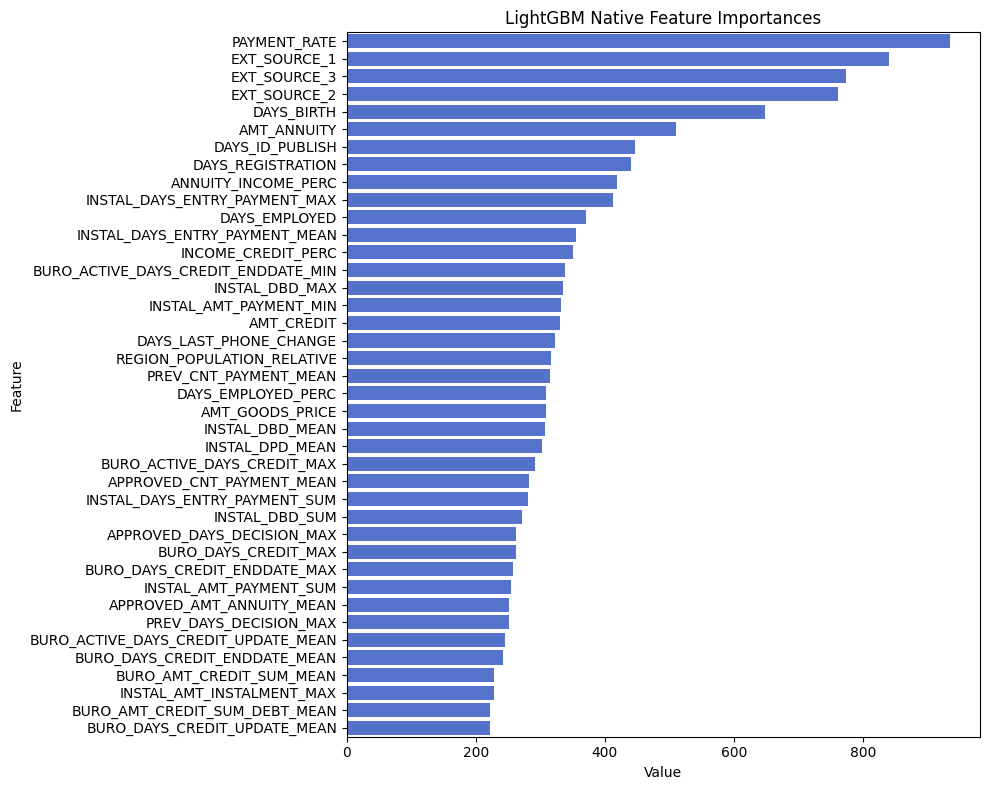

In [40]:
# Extract raw feature importances from the baseline LightGBM model 'm'
feature_imp = pd.DataFrame(
    sorted(zip(m.feature_importances_, X_te.columns)),
    columns=['Value', 'Feature']
)

top_20 = feature_imp.sort_values(by="Value", ascending=False).head(40)

plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=top_20, color='royalblue')
plt.title('LightGBM Native Feature Importances')
plt.tight_layout()
plt.show()

In [41]:
# Explicitly search for our sensitive attributes to see what "model values" they were assigned
sensitive_keywords = ['DAYS_BIRTH', 'CODE_GENDER_F', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_PERC', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'EXT_SOURCE_2']
sensitive_features = feature_imp[feature_imp['Feature'].str.contains('|'.join(sensitive_keywords), case=False, na=False)]

print("\n---- Importance of Sensitive Features (Raw Model Values) ----")
print(sensitive_features.sort_values(by="Value", ascending=False).to_string(index=False))


---- Importance of Sensitive Features (Raw Model Values) ----
 Value            Feature
   841       EXT_SOURCE_1
   774       EXT_SOURCE_3
   761       EXT_SOURCE_2
   648         DAYS_BIRTH
   370      DAYS_EMPLOYED
   309 DAYS_EMPLOYED_PERC
   149      CODE_GENDER_F




---



## Model Audit

In [42]:
!pip install shap fairlearn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 11.5 MB/s eta 0:00:00


In [43]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix,
)
from scipy.stats import ks_2samp
from sklearn.calibration import calibration_curve

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
)

### Define sensitive attributes

In [44]:
# ── Helper: find exact column name by keyword ────────────────────────────
def find_col(keyword, df=X_te):
    matches = [c for c in df.columns if keyword.upper() in c.upper()]
    return matches[0] if matches else None

# ── Sensitive attribute definitions ──────────────────────────────────────
# Each entry: (display_name, binary_array, {0: label, 1: label})
# Binary convention: 0 = privileged group, 1 = unprivileged group

def build_sensitive_attrs():
    attrs = {}

    # 1. Age — already computed as A_te
    attrs['Age'] = {
        'array' : A_te,
        'labels': {0: 'Older (≥25)', 1: 'Young (<25)'},
    }

    # 2. Gender — CODE_GENDER_F = 1 means female after one-hot
    col = find_col('CODE_GENDER_F')
    if col:
        attrs['Gender'] = {
            'array' : X_te[col].values.astype(int),
            'labels': {0: 'Male', 1: 'Female'},
        }
    else:
        print('⚠️  Gender column not found — check one-hot name')

    # 3. Education — Higher education vs other
    col = find_col('Higher_education')
    if col:
        attrs['Education'] = {
            'array' : (1 - X_te[col].values).astype(int),  # flip: 1 = lower ed
            'labels': {0: 'Higher education', 1: 'Lower education'},
        }
    else:
        print('⚠️  Education column not found — check one-hot name')

    # 4. Marital Status — Married vs other
    col = find_col('NAME_FAMILY_STATUS_Married')
    if col:
        attrs['Marital'] = {
            'array' : (1 - X_te[col].values).astype(int),  # flip: 1 = not married
            'labels': {0: 'Married', 1: 'Not married'},
        }
    else:
        print('⚠️  Marital status column not found — check one-hot name')

    # 5. Region rating — REGION_RATING_CLIENT: 1=best, 3=worst
    #    Binarise: 0 = rating 1-2 (good area), 1 = rating 3 (worst area)
    col = find_col('REGION_RATING_CLIENT')
    if col and col in X_te.columns:
        attrs['Region'] = {
            'array' : (X_te[col].values == 3).astype(int),
            'labels': {0: 'Good region (1-2)', 1: 'Poor region (3)'},
        }
    else:
        print('⚠️  Region rating column not found')

    return attrs

SENSITIVE_ATTRS = build_sensitive_attrs()

print('\nSensitive attributes loaded:')
for name, info in SENSITIVE_ATTRS.items():
    arr    = info['array']
    labels = info['labels']
    counts = {labels[g]: (arr == g).sum() for g in np.unique(arr)}
    print(f'  {name:12s} | {counts}')


Sensitive attributes loaded:
  Age          | {'Older (≥25)': np.int64(88544), 'Young (<25)': np.int64(3709)}
  Gender       | {'Male': np.int64(31715), 'Female': np.int64(60538)}
  Education    | {'Higher education': np.int64(22552), 'Lower education': np.int64(69701)}
  Marital      | {'Married': np.int64(59238), 'Not married': np.int64(33015)}
  Region       | {'Good region (1-2)': np.int64(77710), 'Poor region (3)': np.int64(14543)}


### Helper functions

In [45]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_true)) * abs(y_prob[mask].mean() - y_true[mask].mean())
    return ece


def group_metrics(y, s, yhat, A, labels):
    rows = []
    for g, label in labels.items():
        mask = (A == g)
        if mask.sum() < 30:
            continue
        y_g, s_g, yh_g = y[mask], s[mask], yhat[mask]
        if len(np.unique(y_g)) < 2:
            continue
        tn, fp, fn, tp = confusion_matrix(y_g, yh_g, labels=[0, 1]).ravel()
        rows.append({
            'Group'        : label,
            'N'            : int(mask.sum()),
            'Default_rate' : round(1 - y_g.mean(), 4),
            'Approval_rate': round(yh_g.mean(), 4),
            'AUC'          : round(roc_auc_score(y_g, s_g), 4),
            'PR_AUC'       : round(average_precision_score(y_g, s_g), 4),
            'Brier'        : round(brier_score_loss(y_g, s_g), 4),
            'ECE'          : round(expected_calibration_error(y_g, s_g), 4),
            'TPR'          : round(tp / (tp + fn), 4) if (tp + fn) > 0 else np.nan,
            'FPR'          : round(fp / (fp + tn), 4) if (fp + tn) > 0 else np.nan,
        })
    return pd.DataFrame(rows)


def fairness_scalars(y, yhat, A):
    return {
        'DPD': demographic_parity_difference(y, yhat, sensitive_features=A),
        'DPR': demographic_parity_ratio(y, yhat, sensitive_features=A),
        'EOD': equalized_odds_difference(y, yhat, sensitive_features=A),
    }

### Overall performance metrics

In [46]:
auc_overall    = roc_auc_score(y_te, test_pred)
pr_auc_overall = average_precision_score(y_te, test_pred)
brier_overall  = brier_score_loss(y_te, test_pred)
ece_overall    = expected_calibration_error(y_te, test_pred)
ks_stat, _     = ks_2samp(test_pred[y_te == 1], test_pred[y_te == 0])


print('OVERALL PERFORMANCE METRICS')
print(f'ROC-AUC      : {auc_overall:.4f}')
print(f'PR-AUC       : {pr_auc_overall:.4f}  (baseline ≈ {y_te.mean():.3f})')
print(f'Brier Score  : {brier_overall:.4f} ')
print(f'ECE          : {ece_overall:.4f} ')
print(f'KS Statistic : {ks_stat:.4f}  (banking threshold >0.30 → {"PASS" if ks_stat > 0.30 else "FAIL"})')

OVERALL PERFORMANCE METRICS
ROC-AUC      : 0.7874
PR-AUC       : 0.9737  (baseline ≈ 0.919)
Brier Score  : 0.0657 
ECE          : 0.0024 
KS Statistic : 0.4335  (banking threshold >0.30 → PASS)


From the performance metrics, the model is structually sounded and has high predictive power.

Key insights:
- A Brier score close to zero indicates that the predicted default probabilities are highly accurate
- The Expected Calibration Error is practically zero. This is a massive win for model governance. It means the model is not overconfident or underconfident
- The Kolmogorov-Smirnov statistic measures the maximum separation between the cumulative distribution of good and bad loans. In consumer credit risk, a KS > 0.30 is the gold standard

## Inspect attributes' approval rate and EOD

In [47]:
y_pred = (test_pred > tau).astype(int)

from fairlearn.metrics import equalized_odds_difference
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

audit_results = []

def evaluate_bias(attribute_name, group_series, group1, group2):
    rate1 = (y_pred[group_series == group1] == 1).mean()
    rate2 = (y_pred[group_series == group2] == 1).mean()
    score = equalized_odds_difference(y_true=y_te, y_pred=y_pred, sensitive_features=group_series)
    audit_results.append({'Attribute': attribute_name, 'Subgroup': f"{attribute_name}: {group1}", 'Approval Rate': rate1, 'EO_Diff': score})
    audit_results.append({'Attribute': attribute_name, 'Subgroup': f"{attribute_name}: {group2}", 'Approval Rate': rate2, 'EO_Diff': score})

if 'CODE_GENDER_F' in X_te.columns:
    gender_series = np.where(X_te['CODE_GENDER_F'] == 1, 'Female', 'Male')
    evaluate_bias("Gender", gender_series, "Male", "Female")

# FIX v6: AGE_GROUP was excluded from feats so it is NOT in X_te.
# Use the pre-computed A_te array (0 = older>=25, 1 = young<25) instead.
age_series = np.where(A_te == 1, 'Under 25', '25 and over')
evaluate_bias("Age", age_series, "25 and over", "Under 25")

if 'DAYS_EMPLOYED' in X_te.columns:
    employed_series = np.where(X_te['DAYS_EMPLOYED'] > -730, 'Employed < 2 Yrs', 'Employed 2+ Yrs')
    evaluate_bias("Employment", employed_series, 'Employed 2+ Yrs', 'Employed < 2 Yrs')

if 'EXT_SOURCE_3' in X_te.columns:
    ext3_median = X_te['EXT_SOURCE_3'].median()
    ext3_series = np.where(X_te['EXT_SOURCE_3'] >= ext3_median, 'High EXT_3', 'Low EXT_3')
    evaluate_bias("External Rating", ext3_series, 'High EXT_3', 'Low EXT_3')

if 'PAYMENT_RATE' in X_te.columns:
    pay_median = X_te['PAYMENT_RATE'].median()
    pay_series = np.where(X_te['PAYMENT_RATE'] <= pay_median, 'Low Pay Rate', 'High Pay Rate')
    evaluate_bias("Repayment Speed", pay_series, 'Low Pay Rate', 'High Pay Rate')

if 'EXT_SOURCE_2' in X_te.columns:
    ext2_median = X_te['EXT_SOURCE_2'].median()
    ext2_series = np.where(X_te['EXT_SOURCE_2'] >= ext2_median, 'High EXT_2', 'Low EXT_2')
    evaluate_bias("Ext Source 2 Rating", ext2_series, 'High EXT_2', 'Low EXT_2')

if 'OWN_CAR_AGE' in X_te.columns:
    car_series = np.where(X_te['OWN_CAR_AGE'].isna() | (X_te['OWN_CAR_AGE'] > 10), 'Old/No Car', 'New Car')
    evaluate_bias("Car Ownership", car_series, 'New Car', 'Old/No Car')

if 'AMT_CREDIT' in X_te.columns:
    credit_median = X_te['AMT_CREDIT'].median()
    credit_series = np.where(X_te['AMT_CREDIT'] <= credit_median, 'Smaller Loan', 'Larger Loan')
    evaluate_bias("Loan Magnitude", credit_series, 'Smaller Loan', 'Larger Loan')

if 'FLAG_DOCUMENT_3' in X_te.columns:
    doc_series = np.where(X_te['FLAG_DOCUMENT_3'] == 1, 'Provided Doc 3', 'No Doc 3')
    evaluate_bias("Documentation", doc_series, 'Provided Doc 3', 'No Doc 3')

if 'TOTALAREA_MODE' in X_te.columns:
    area_median = X_te['TOTALAREA_MODE'].median()
    area_series = np.where(X_te['TOTALAREA_MODE'] >= area_median, 'Large Living Area', 'Small Living Area')
    evaluate_bias("Living Conditions", area_series, 'Large Living Area', 'Small Living Area')

if 'REGION_POPULATION_RELATIVE' in X_te.columns:
    pop_median = X_te['REGION_POPULATION_RELATIVE'].median()
    pop_series = np.where(X_te['REGION_POPULATION_RELATIVE'] > pop_median, 'High Density', 'Low Density')
    evaluate_bias("Population Density", pop_series, 'Low Density', 'High Density')

if 'CNT_CHILDREN' in X_te.columns:
    child_series = np.where(X_te['CNT_CHILDREN'] > 0, 'Has Children', 'No Children')
    evaluate_bias("Parental Status", child_series, 'No Children', 'Has Children')

if 'NAME_FAMILY_STATUS_Married' in X_te.columns:
    fam_series = np.where(X_te['NAME_FAMILY_STATUS_Married'] == 1, 'Married', 'Not Married')
    evaluate_bias("Family Status", fam_series, 'Married', 'Not Married')

if 'NAME_EDUCATION_TYPE_Higher_education' in X_te.columns:
    edu_series = np.where(X_te['NAME_EDUCATION_TYPE_Higher_education'] == 1, 'Higher Ed', 'Secondary/Other')
    evaluate_bias("Education", edu_series, 'Higher Ed', 'Secondary/Other')

if 'AMT_REQ_CREDIT_BUREAU_YEAR' in X_te.columns:
    bureau_series = np.where(X_te['AMT_REQ_CREDIT_BUREAU_YEAR'] <= 1, 'Rare Queries', 'Frequent Queries')
    evaluate_bias("Bureau History", bureau_series, 'Rare Queries', 'Frequent Queries')

df_audit = pd.DataFrame(audit_results)


In [48]:
df_audit

,Attribute,Subgroup,Approval Rate,EO_Diff
0,Gender,Gender: Male,0.425571,0.154677
1,Gender,Gender: Female,0.585929,0.154677
2,Age,Age: 25 and over,0.543346,0.319289
3,Age,Age: Under 25,0.231329,0.319289
4,Employment,Employment: Employed 2+ Yrs,0.571434,0.204498
5,Employment,Employment: Employed < 2 Yrs,0.361668,0.204498
6,External Rating,External Rating: High EXT_3,0.656960,0.310118
7,External Rating,External Rating: Low EXT_3,0.338235,0.310118
8,Repayment Speed,Repayment Speed: Low Pay Rate,0.553595,0.053124
9,Repayment Speed,Repayment Speed: High Pay Rate,0.498775,0.053124


### Per-Group Audit — All Sensitive Attributes

In [49]:
all_group_dfs  = {}
all_scalar_dfs = {}

for attr_name, info in SENSITIVE_ATTRS.items(): # loop over sensitive attributes to check
    A   = info['array']
    lbl = info['labels']

    print(f'ATTRIBUTE: {attr_name}  |  Groups: {list(lbl.values())}')
    print('-' * 60)

    # Per-group performance
    gdf = group_metrics(y_te, test_pred, yhat_te, A, lbl)
    all_group_dfs[attr_name] = gdf
    print(gdf.to_string(index=False))

    # Gaps (best minus worst group)
    if len(gdf) >= 2:
        print(f"\n  AUC gap           : {gdf['AUC'].max() - gdf['AUC'].min():.4f}")
        print(f"  Approval rate gap : {gdf['Approval_rate'].max() - gdf['Approval_rate'].min():.4f}")
        print(f"  TPR gap           : {gdf['TPR'].max() - gdf['TPR'].min():.4f}")
        print(f"  ECE gap           : {gdf['ECE'].max() - gdf['ECE'].min():.4f}")

    # Fairness scalars
    sc  = fairness_scalars(y_te, yhat_te, A)
    all_scalar_dfs[attr_name] = sc
    print(f"\n  DPD  : {sc['DPD']:.4f}  (Independence — 0 = fair)")
    print(f"  DPR  : {sc['DPR']:.4f}  (Disparate Impact — legal threshold ≥0.80 → {'PASS' if sc['DPR'] >= 0.80 else 'FAIL !!!'})")
    print(f"  EOD  : {sc['EOD']:.4f}  (Separation — 0 = fair)")
    print()

ATTRIBUTE: Age  |  Groups: ['Older (≥25)', 'Young (<25)']
------------------------------------------------------------
      Group     N  Default_rate  Approval_rate    AUC  PR_AUC  Brier    ECE    TPR    FPR
Older (≥25) 88544        0.0791         0.5433 0.7882  0.9743 0.0644 0.0028 0.5752 0.1725
Young (<25)  3709        0.1202         0.2313 0.7522  0.9525 0.0955 0.0149 0.2559 0.0516

  AUC gap           : 0.0360
  Approval rate gap : 0.3120
  TPR gap           : 0.3193
  ECE gap           : 0.0121

  DPD  : 0.3120  (Independence — 0 = fair)
  DPR  : 0.4257  (Disparate Impact — legal threshold ≥0.80 → FAIL !!!)
  EOD  : 0.3193  (Separation — 0 = fair)

ATTRIBUTE: Gender  |  Groups: ['Male', 'Female']
------------------------------------------------------------
 Group     N  Default_rate  Approval_rate    AUC  PR_AUC  Brier    ECE    TPR    FPR
  Male 31715        0.1012         0.4256 0.7773  0.9650 0.0802 0.0049 0.4602 0.1178
Female 60538        0.0700         0.5859 0.7875  0.9772 

a Disparate Impact Ratio (DPR) below 0.80 establishes a prima facie case for discrimination.

**Observation**:
- Age, Gender, Education, and Region all fail the 0.80 threshold!
- EOD of Age is huge --> The model is effectively applying a blanket rejection to the young cohort. Young is less likely to be accepted comparing to older people.
- Males are the penalized group here (Approval: 38% vs Female: 55%). Males have a much higher baseline default rate (10.1% vs 7.0%)
- Marital status can be ignored and doesnt required any further debias

**Next step**: apply mitigation strategies (e.g., Threshold Calibration or EqOddsPostprocessing) targeting Age and Region first.

### Fairness summary table

- Consolidates all fairness scalars into one table for easy comparison.  
- Sort by EOD descending to identify the most urgent attribute to debias.

In [50]:
summary_rows = []
for attr_name, sc in all_scalar_dfs.items():
    gdf = all_group_dfs[attr_name]
    summary_rows.append({
        'Attribute'          : attr_name,
        'Groups'             : ' vs '.join(SENSITIVE_ATTRS[attr_name]['labels'].values()),
        'DPD'                : round(sc['DPD'], 4),
        'DPR'                : round(sc['DPR'], 4),
        'Legal_pass (≥0.80)' : '✅' if sc['DPR'] >= 0.80 else '⚠️',
        'EOD'                : round(sc['EOD'], 4),
        'AUC_gap'            : round(gdf['AUC'].max() - gdf['AUC'].min(), 4) if len(gdf) >= 2 else np.nan,
        'Approval_gap'       : round(gdf['Approval_rate'].max() - gdf['Approval_rate'].min(), 4) if len(gdf) >= 2 else np.nan,
        'TPR_gap'            : round(gdf['TPR'].max() - gdf['TPR'].min(), 4) if len(gdf) >= 2 else np.nan,
        'ECE_gap'            : round(gdf['ECE'].max() - gdf['ECE'].min(), 4) if len(gdf) >= 2 else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('EOD', ascending=False)

print('FAIRNESS SUMMARY — ALL SENSITIVE ATTRIBUTES')
print('(Sorted by Equalized Odds Difference — highest = most urgent to fix)')
print(summary_df.to_string(index=False, float_format='%.4f'))

print('\nLegend:')
print('  DPD = Demographic Parity Difference  (Independence)')
print('  DPR = Disparate Impact Ratio         (Independence — legal threshold ≥0.80)')
print('  EOD = Equalized Odds Difference      (Separation)')
print('  *_gap = max minus min across groups  (AUC/approval/TPR/ECE)')

FAIRNESS SUMMARY — ALL SENSITIVE ATTRIBUTES
(Sorted by Equalized Odds Difference — highest = most urgent to fix)
Attribute                               Groups    DPD    DPR Legal_pass (≥0.80)    EOD  AUC_gap  Approval_gap  TPR_gap  ECE_gap
      Age           Older (≥25) vs Young (<25) 0.3120 0.4257                 ⚠️ 0.3193   0.0360        0.3120   0.3193   0.0121
Education  Higher education vs Lower education 0.1938 0.7139                 ⚠️ 0.1832   0.0052        0.1938   0.1832   0.0012
   Region Good region (1-2) vs Poor region (3) 0.1615 0.7097                 ⚠️ 0.1552   0.0038        0.1615   0.1552   0.0053
   Gender                       Male vs Female 0.1604 0.7263                 ⚠️ 0.1547   0.0102        0.1603   0.1547   0.0033
  Marital               Married vs Not married 0.0658 0.8813                  ✅ 0.0630   0.0130        0.0657   0.0630   0.0026

Legend:
  DPD = Demographic Parity Difference  (Independence)
  DPR = Disparate Impact Ratio         (Independence — l

### Calibration — ECE & Reliability Diagram by Attribute

Sufficiency check: if the model assigns the same score to two applicants  
from different groups, their actual default rate should be the same.  
Deviation from the diagonal = miscalibration = sufficiency violation.

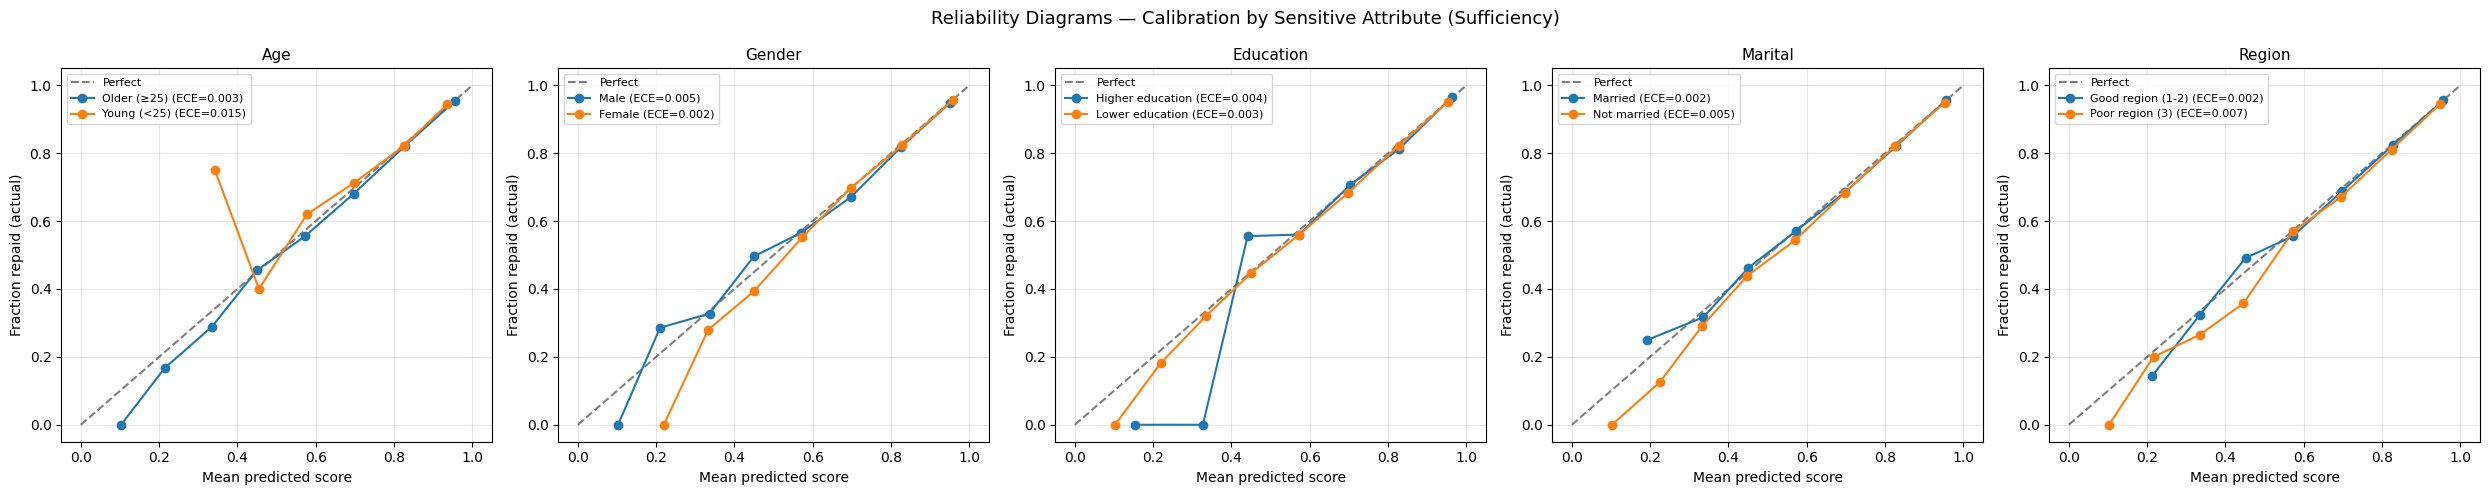

In [51]:
n_attrs = len(SENSITIVE_ATTRS)
fig, axes = plt.subplots(1, n_attrs, figsize=(5 * n_attrs, 5))
if n_attrs == 1:
    axes = [axes]

fig.suptitle('Reliability Diagrams — Calibration by Sensitive Attribute (Sufficiency)', fontsize=13)

for ax, (attr_name, info) in zip(axes, SENSITIVE_ATTRS.items()):
    A   = info['array']
    lbl = info['labels']
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')

    for g, label in lbl.items():
        mask = (A == g)
        if mask.sum() < 50 or len(np.unique(y_te[mask])) < 2:
            continue
        frac_pos, mean_pred = calibration_curve(y_te[mask], test_pred[mask], n_bins=8)
        ece_g = expected_calibration_error(y_te[mask], test_pred[mask])
        ax.plot(mean_pred, frac_pos, 'o-', label=f'{label} (ECE={ece_g:.3f})')

    ax.set_title(attr_name, fontsize=11)
    ax.set_xlabel('Mean predicted score')
    ax.set_ylabel('Fraction repaid (actual)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
# Build a DataFrame of all sensitive attribute arrays
sensitive_df = pd.DataFrame({
    attr_name: info['array']
    for attr_name, info in SENSITIVE_ATTRS.items()
})

mf = MetricFrame(
    metrics={
        'accuracy'      : lambda y, yh: (y == yh).mean(),
        'selection_rate': selection_rate,
        'tpr'           : true_positive_rate,
        'fpr'           : false_positive_rate,
    },
    y_true=y_te,
    y_pred=yhat_te,
    sensitive_features=sensitive_df,
)

print('METRICFRAME — OVERALL')
print(mf.overall.to_string())

print('\nMETRICFRAME — BY GROUP (showing all intersections)')
print(mf.by_group.to_string(float_format='%.4f'))

print('\nMETRICFRAME — DIFFERENCE (worst - best group across all intersections)')
print(mf.difference().to_string())

print('\nMETRICFRAME — RATIO (worst / best)')
print(mf.ratio().to_string())

METRICFRAME — OVERALL
accuracy          0.584848
selection_rate    0.530801
tpr               0.562903
fpr               0.165279

METRICFRAME — BY GROUP (showing all intersections)
                                     accuracy  selection_rate    tpr    fpr
Age Gender Education Marital Region                                        
0   0      0         0       0         0.7096          0.6888 0.7099 0.2961
                             1         0.5416          0.4853 0.5145 0.1379
                     1       0         0.5677          0.5122 0.5438 0.1862
                             1         0.3904          0.3108 0.3362 0.0455
           1         0       0         0.5192          0.4541 0.4853 0.1361
                             1         0.4059          0.2903 0.3235 0.0852
                     1       0         0.4057          0.2873 0.3215 0.0775
                             1         0.3232          0.1438 0.1718 0.0223
    1      0         0       0         0.7704          0.7

In [53]:
CF_FLIP_MAP = {
    'Age'     : ('DAYS_BIRTH',   -20 * 365, -30 * 365),   # flip young↔old
    'Gender'  : ('CODE_GENDER_F', 0, 1),                   # flip M↔F
    'Education': ('NAME_EDUCATION_TYPE_Higher_education', 0, 1),
    'Marital' : ('NAME_FAMILY_STATUS_Married', 0, 1),
    'Region'  : ('REGION_RATING_CLIENT', 1, 3),            # flip good↔poor region
}

np.random.seed(SEED)
sample_size = min(2000, len(X_te))
sample_idx  = np.random.choice(len(X_te), sample_size, replace=False)
X_sample    = X_te.iloc[sample_idx].copy().reset_index(drop=True)
s_original  = m.predict_proba(X_sample)[:, 1]

cf_results = []
for attr_name, (col, val_priv, val_unpriv) in CF_FLIP_MAP.items():
    if col not in X_sample.columns:
        print(f'⚠️  {attr_name}: column "{col}" not found — skipping')
        continue

    X_cf = X_sample.copy()
    # flip: privileged → unprivileged and vice versa
    priv_mask   = (X_cf[col] == val_priv)
    unpriv_mask = (X_cf[col] == val_unpriv)
    X_cf.loc[priv_mask,   col] = val_unpriv
    X_cf.loc[unpriv_mask, col] = val_priv

    X_cf[col] = X_cf[col].astype(int)

    # For age: also update DAYS_EMPLOYED_PERC which depends on DAYS_BIRTH
    if attr_name == 'Age' and 'DAYS_EMPLOYED_PERC' in X_cf.columns:
        X_cf['DAYS_EMPLOYED_PERC'] = X_cf['DAYS_EMPLOYED'] / X_cf['DAYS_BIRTH']

    s_cf = m.predict_proba(X_cf)[:, 1]
    diff = np.abs(s_cf - s_original)

    cf_results.append({
        'Attribute'          : attr_name,
        'Flipped_column'     : col,
        'Mean_|Δscore|'      : round(diff.mean(), 4),
        'Max_|Δscore|'       : round(diff.max(), 4),
        'Cases_>0.05_change' : f'{(diff > 0.05).mean():.1%}',
        'Cases_>0.10_change' : f'{(diff > 0.10).mean():.1%}',
    })

cf_df = pd.DataFrame(cf_results).sort_values('Mean_|Δscore|', ascending=False)
print('COUNTERFACTUAL FAIRNESS — ALL SENSITIVE ATTRIBUTES')
print('(Higher mean |Δscore| = model relies more on this attribute or its proxies)')
print(cf_df.to_string(index=False))

COUNTERFACTUAL FAIRNESS — ALL SENSITIVE ATTRIBUTES
(Higher mean |Δscore| = model relies more on this attribute or its proxies)
Attribute                       Flipped_column  Mean_|Δscore|  Max_|Δscore| Cases_>0.05_change Cases_>0.10_change
   Gender                        CODE_GENDER_F         0.0158        0.1420               5.9%               1.1%
Education NAME_EDUCATION_TYPE_Higher_education         0.0111        0.1205               3.9%               0.4%
  Marital           NAME_FAMILY_STATUS_Married         0.0073        0.1779               0.9%               0.1%
      Age                           DAYS_BIRTH         0.0006        0.0475               0.0%               0.0%
   Region                 REGION_RATING_CLIENT         0.0004        0.0228               0.0%               0.0%


Direct Discrimination: Gender & Education
- 6.6% of all applicants experienced a score swing of more than 5%
- Considering `Max_|Δscore|` there is an applicant whose predicted risk of default shifted by nearly 20% purely by flipping their gender from Male to Female.

### Master summary table

In [54]:
master_rows = []

# Overall row
master_rows.append({
    'Section'  : 'Overall',
    'Attribute': '—',
    'Metric'   : 'ROC-AUC',
    'Before'   : f'{auc_overall:.4f}',
    'After'    : '—',
})
master_rows.append({'Section': 'Overall', 'Attribute': '—', 'Metric': 'PR-AUC',
                    'Before': f'{pr_auc_overall:.4f}', 'After': '—'})
master_rows.append({'Section': 'Overall', 'Attribute': '—', 'Metric': 'Brier Score',
                    'Before': f'{brier_overall:.4f}', 'After': '—'})
master_rows.append({'Section': 'Overall', 'Attribute': '—', 'Metric': 'KS Statistic',
                    'Before': f'{ks_stat:.4f}', 'After': '—'})

# Per-attribute fairness rows
for attr_name, sc in all_scalar_dfs.items():
    gdf = all_group_dfs[attr_name]
    for metric, val in [
        ('DPD (Independence)',       f"{sc['DPD']:.4f}"),
        ('DPR (Disparate Impact)',   f"{sc['DPR']:.4f}  {'✅' if sc['DPR'] >= 0.80 else '⚠️'}"),
        ('EOD (Separation)',         f"{sc['EOD']:.4f}"),
        ('Approval gap',             f"{gdf['Approval_rate'].max() - gdf['Approval_rate'].min():.4f}" if len(gdf) >= 2 else '—'),
        ('TPR gap',                  f"{gdf['TPR'].max() - gdf['TPR'].min():.4f}" if len(gdf) >= 2 else '—'),
        ('ECE gap (Sufficiency)',    f"{gdf['ECE'].max() - gdf['ECE'].min():.4f}" if len(gdf) >= 2 else '—'),
    ]:
        master_rows.append({
            'Section'  : 'Fairness',
            'Attribute': attr_name,
            'Metric'   : metric,
            'Before'   : val,
            'After'    : '—',
        })

# Counterfactual rows
for _, row in cf_df.iterrows():
    master_rows.append({
        'Section'  : 'Counterfactual',
        'Attribute': row['Attribute'],
        'Metric'   : 'Mean |Δscore|',
        'Before'   : str(row['Mean_|Δscore|']),
        'After'    : '—',
    })

master_df = pd.DataFrame(master_rows)
print('MASTER SUMMARY TABLE')
print('(Fill \'After\' column after Step 5 improvement)')
print(master_df.to_string(index=False))

MASTER SUMMARY TABLE
(Fill 'After' column after Step 5 improvement)
       Section Attribute                 Metric     Before After
       Overall         —                ROC-AUC     0.7874     —
       Overall         —                 PR-AUC     0.9737     —
       Overall         —            Brier Score     0.0657     —
       Overall         —           KS Statistic     0.4335     —
      Fairness       Age     DPD (Independence)     0.3120     —
      Fairness       Age DPR (Disparate Impact) 0.4257  ⚠️     —
      Fairness       Age       EOD (Separation)     0.3193     —
      Fairness       Age           Approval gap     0.3120     —
      Fairness       Age                TPR gap     0.3193     —
      Fairness       Age  ECE gap (Sufficiency)     0.0121     —
      Fairness    Gender     DPD (Independence)     0.1604     —
      Fairness    Gender DPR (Disparate Impact) 0.7263  ⚠️     —
      Fairness    Gender       EOD (Separation)     0.1547     —
      Fairness    Gend



---



## SHAP Analysis

In [55]:
import shap

### Compute SHAP values

In [56]:
np.random.seed(SEED)

shap_idx = np.random.choice(len(X_te), min(10000, len(X_te)), replace=False)
X_shap   = X_te.iloc[shap_idx].reset_index(drop=True)

# SHAP arrays for each sensitive attribute
A_shap_dict = {attr_name: info['array'][shap_idx] for attr_name, info in SENSITIVE_ATTRS.items()}

explainer   = shap.TreeExplainer(m)
shap_values = explainer.shap_values(X_shap)

# FIX v6: LightGBM binary classification may return either
#   (a) a 2D array of shape (n, p)  — older shap versions
#   (b) a list [neg_class_arr, pos_class_arr]  — newer shap versions
# Normalise to a single 2D array of SHAP values for the positive class (y=1).
if isinstance(shap_values, list):
    sv = np.array(shap_values[1])   # positive-class SHAP values
else:
    sv = np.array(shap_values)       # already (n, p)

# Reassign shap_values to positive-class array so summary_plot works correctly
shap_values = sv


### Global SHAP summary (consider all applicants)

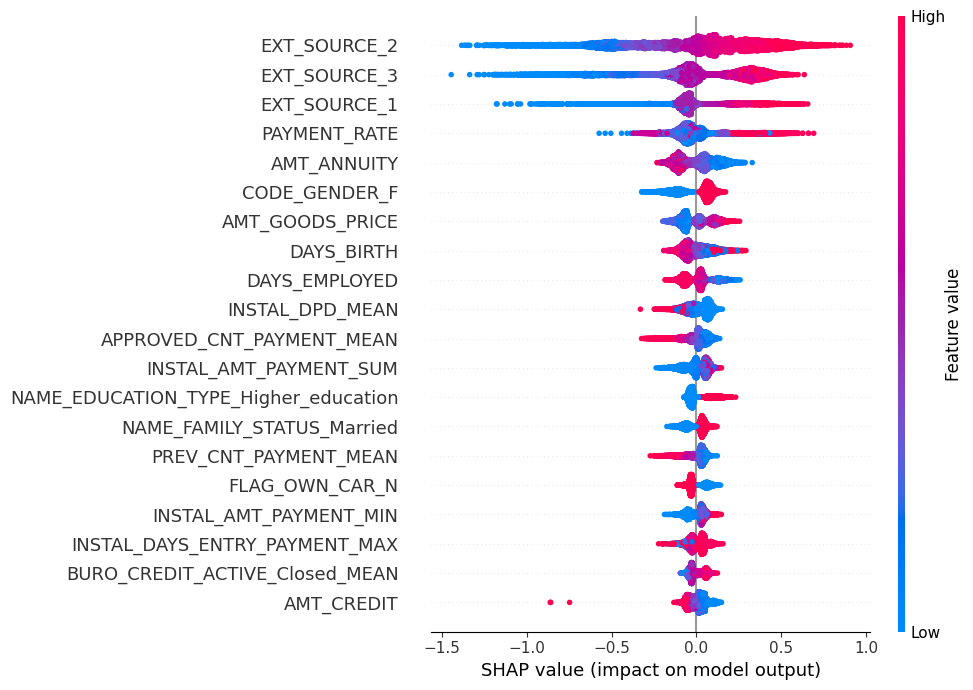

In [57]:
shap.summary_plot(shap_values, X_shap, max_display=20, plot_type='dot',show=True, plot_size=(10, 7))

Insights
- Top three drivers are EXT_SOURCE which is external credit bureau score. These are strong predictive signals



### Proxy analysis (each sensitive attributes)

In [58]:
all_proxy_dfs = {}   # store proxy results per attribute

for attr_name, A_shap in A_shap_dict.items():
    lbl = SENSITIVE_ATTRS[attr_name]['labels']
    groups = [g for g in lbl if g in np.unique(A_shap)]
    if len(groups) < 2:
        continue

    g0, g1 = groups[0], groups[1]
    mask0 = (A_shap == g0)
    mask1 = (A_shap == g1)

    if mask0.sum() < 10 or mask1.sum() < 10:
        continue

    shap_g0 = np.abs(sv[mask0]).mean(axis=0)
    shap_g1 = np.abs(sv[mask1]).mean(axis=0)

    proxy_rows = []
    for i, feat in enumerate(X_shap.columns):
        corr = X_shap[feat].fillna(X_shap[feat].median()).corr(
            pd.Series(A_shap.astype(float))
        )
        shap_diff = abs(shap_g0[i] - shap_g1[i])
        proxy_rows.append({
            'feature'   : feat,
            'abs_corr'  : abs(corr),
            'shap_diff' : shap_diff,
            'proxy_risk': 'HIGH' if abs(corr) > 0.15 and shap_diff > 0.005 else
                          'MED'  if abs(corr) > 0.08 else 'LOW',
        })

    proxy_df = (pd.DataFrame(proxy_rows)
                  .sort_values('abs_corr', ascending=False)
                  .head(14)
                  .reset_index(drop=True))
    all_proxy_dfs[attr_name] = proxy_df

    print('-' * 60)
    print(f'{attr_name}  ({lbl[g0]} vs {lbl[g1]})')
    print('-' * 60)
    print(proxy_df.to_string(index=False, float_format='%.4f'))

    high_risk = proxy_df[proxy_df.proxy_risk.str.startswith('HIGH')]['feature'].tolist()
    if high_risk:
        print(f'\nHIGH-RISK PROXIES FOR {attr_name}: {high_risk}\n')

------------------------------------------------------------
Age  (Older (≥25) vs Young (<25))
------------------------------------------------------------
                                feature  abs_corr  shap_diff proxy_risk
                             DAYS_BIRTH    0.3431     0.0536       HIGH
                        DAYS_ID_PUBLISH    0.2578     0.0030        MED
                   BURO_DAYS_CREDIT_MIN    0.2039     0.0059       HIGH
NAME_FAMILY_STATUS_Single_/_not_married    0.2018     0.0013        MED
                           EXT_SOURCE_1    0.1938     0.0538       HIGH
                  BURO_DAYS_CREDIT_MEAN    0.1843     0.0035        MED
         NAME_HOUSING_TYPE_With_parents    0.1778     0.0010        MED
                 PREV_DAYS_DECISION_MIN    0.1734     0.0035        MED
             APPROVED_DAYS_DECISION_MIN    0.1725     0.0002        MED
  NAME_EDUCATION_TYPE_Incomplete_higher    0.1595     0.0020        MED
            APPROVED_DAYS_DECISION_MEAN    0.1515   

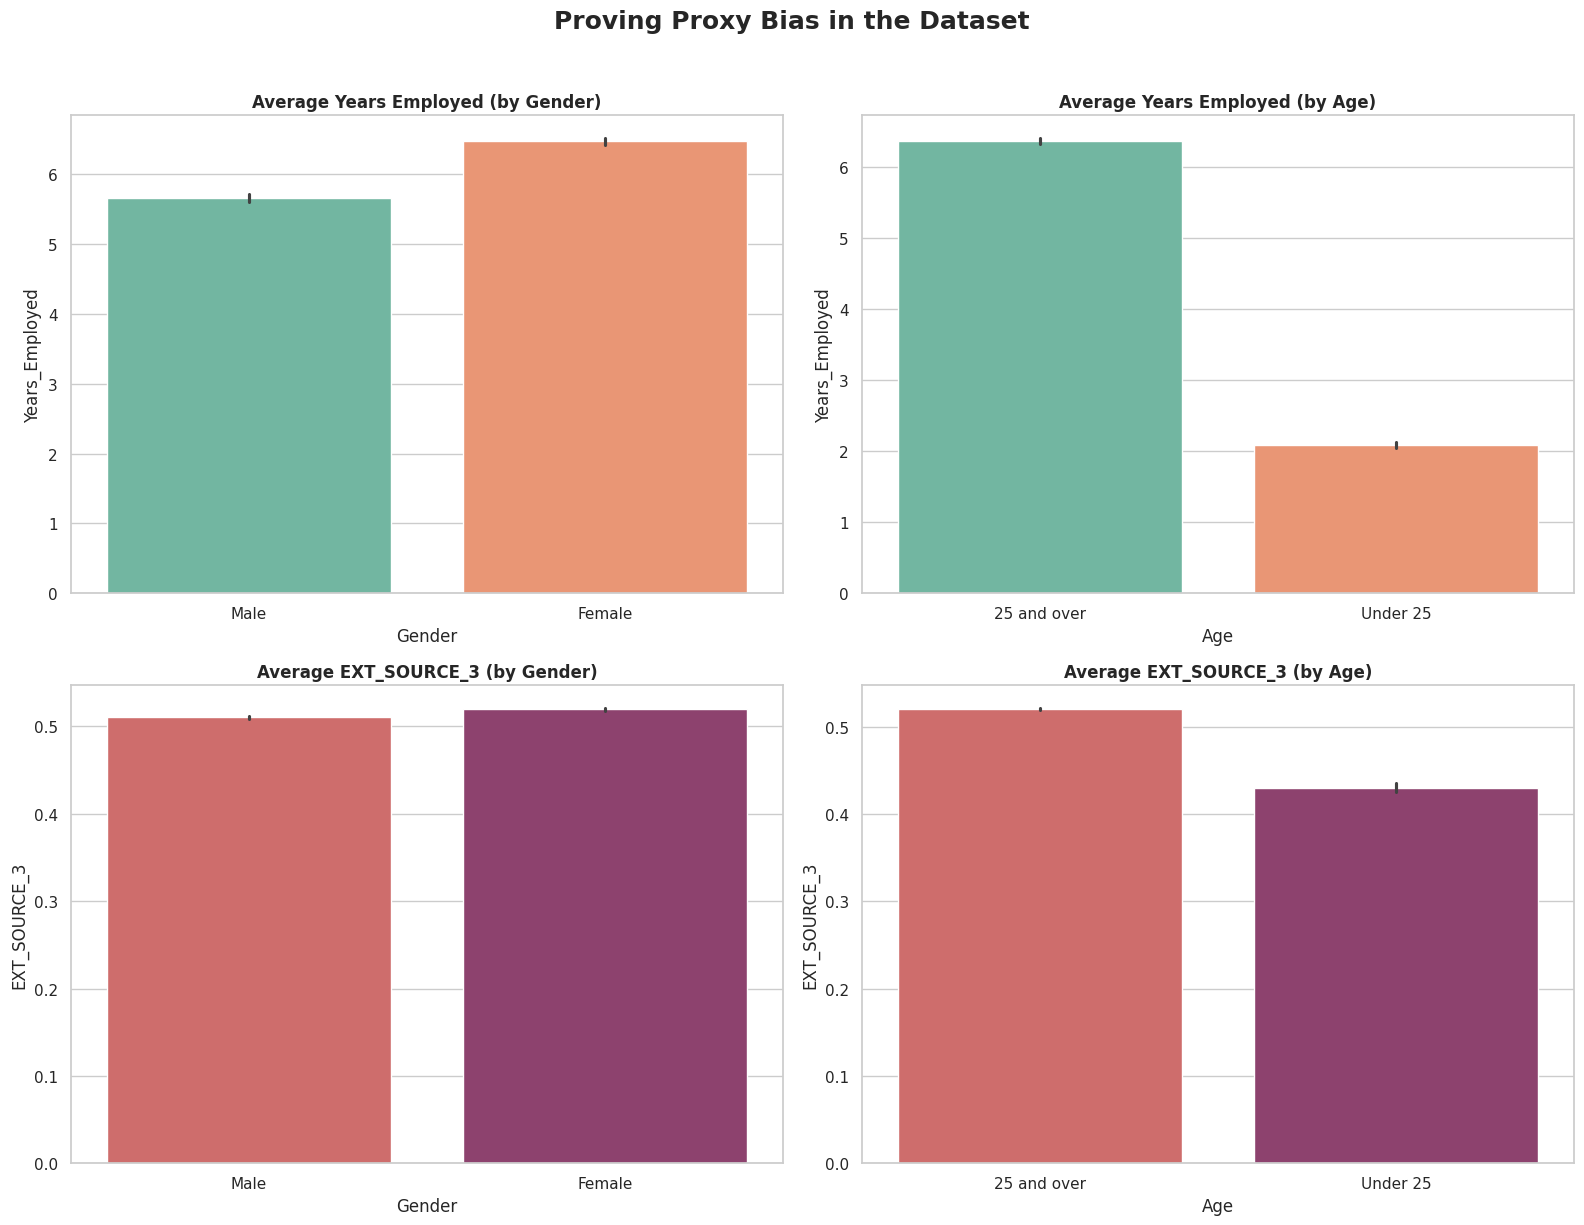

--- Proxy Statistics ---

Average Years Employed by Gender:
Gender
Female    6.471648
Male      5.660131
Name: Years_Employed, dtype: float64

Average EXT_SOURCE_3 by Age:
Age
25 and over    0.520067
Under 25       0.430173
Name: EXT_SOURCE_3, dtype: float64


In [59]:
X_proxy = X_te.copy()
X_proxy['Gender'] = np.where(X_proxy['CODE_GENDER_F'] == 1, 'Female', 'Male')

if 'DAYS_BIRTH' in X_proxy.columns:
    X_proxy['Age'] = np.where((-X_proxy['DAYS_BIRTH'] / 365.25) < 25, 'Under 25', '25 and over')

# Convert negative days to positive years for readability
if 'DAYS_EMPLOYED' in X_proxy.columns:
    X_proxy['Years_Employed'] = X_proxy['DAYS_EMPLOYED'] / -365.25

# Visualizing the Discrepancies
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=X_proxy, x="Gender", y="Years_Employed", palette="Set2", ax=axes[0,0])
axes[0,0].set_title("Average Years Employed (by Gender)", fontweight='bold')

if 'Age' in X_proxy.columns:
    sns.barplot(data=X_proxy, x="Age", y="Years_Employed", palette="Set2", ax=axes[0,1])
    axes[0,1].set_title("Average Years Employed (by Age)", fontweight='bold')

    sns.barplot(data=X_proxy, x="Age", y="EXT_SOURCE_3", palette="flare", ax=axes[1,1])
    axes[1,1].set_title("Average EXT_SOURCE_3 (by Age)", fontweight='bold')

sns.barplot(data=X_proxy, x="Gender", y="EXT_SOURCE_3", palette="flare", ax=axes[1,0])
axes[1,0].set_title("Average EXT_SOURCE_3 (by Gender)", fontweight='bold')

plt.suptitle("Proving Proxy Bias in the Dataset", fontsize=18, fontweight='heavy', y=1.02)
plt.tight_layout()
plt.show()

print("--- Proxy Statistics ---")
print("\nAverage Years Employed by Gender:")
print(X_proxy.groupby('Gender')['Years_Employed'].mean())

if 'Age' in X_proxy.columns:
    print("\nAverage EXT_SOURCE_3 by Age:")
    print(X_proxy.groupby('Age')['EXT_SOURCE_3'].mean())

- massive proxy bias against young people
- ext3 actually favour women than men -> find another features that against women

In [60]:
# ---------------------------------------------------------
# 1. PROVING YOUTH PROXY BIAS VIA SHAP PENALTIES
# ---------------------------------------------------------
print('[ Proving Age Proxy Bias ]')
emp_idx = X_shap.columns.get_loc('DAYS_EMPLOYED')

is_youth = (-X_shap['DAYS_BIRTH'] / 365.25) < 25
is_adult = (-X_shap['DAYS_BIRTH'] / 365.25) >= 25

# FIX v6: shap_values is now consistently a 2D (n, p) array (positive class)
youth_shap = shap_values[is_youth.values, emp_idx].mean()
adult_shap = shap_values[is_adult.values, emp_idx].mean()

print(f'Average SHAP value for DAYS_EMPLOYED — Adults : {adult_shap:.4f}')
print(f'Average SHAP value for DAYS_EMPLOYED — Youth  : {youth_shap:.4f}')
if youth_shap < adult_shap:
    print('→ PROOF: Employment contributes LESS to the model score for Youth,'
          ' consistent with shorter histories penalising them via EXT_SOURCE proxies.\n')
else:
    print('→ Employment SHAP is higher for Youth — their shorter histories may actually'
          ' push scores upward (check sign carefully).\n')

# ---------------------------------------------------------
# 2. SCANNING FOR THE HIDDEN GENDER PROXY
# ---------------------------------------------------------
print('[ Scanning the Top 20 Features for Gender Gaps ]')
top_features = feature_imp.sort_values(by='Value', ascending=False).head(20)['Feature'].tolist()

disparities_found = False
for feat in top_features:
    if 'GENDER' in feat or 'AGE' in feat or 'BIRTH' in feat:
        continue
    if feat not in X_proxy.columns:
        continue
    female_avg = X_proxy[X_proxy['Gender'] == 'Female'][feat].mean()
    male_avg   = X_proxy[X_proxy['Gender'] == 'Male'][feat].mean()
    if male_avg != 0 and pd.notna(male_avg) and pd.notna(female_avg):
        diff_pct = (abs(female_avg - male_avg) / abs(male_avg)) * 100
        if diff_pct > 15:
            disparities_found = True
            print(f'{feat:25s} | Men: {male_avg:10.2f} | Women: {female_avg:10.2f} | Gap: {diff_pct:.1f}%')

if not disparities_found:
    print('\nNo extreme neutral proxy gaps found. Bias likely driven directly by CODE_GENDER_F.')


[ Proving Age Proxy Bias ]
Average SHAP value for DAYS_EMPLOYED — Adults : 0.0051
Average SHAP value for DAYS_EMPLOYED — Youth  : -0.0536
→ PROOF: Employment contributes LESS to the model score for Youth, consistent with shorter histories penalising them via EXT_SOURCE proxies.

[ Scanning the Top 20 Features for Gender Gaps ]
INCOME_CREDIT_PERC        | Men:       0.45 | Women:       0.38 | Gap: 16.9%
BURO_ACTIVE_DAYS_CREDIT_ENDDATE_MIN | Men:     861.99 | Women:     718.27 | Gap: 16.7%


- It is biased against Young People because it inherits systemic prejudice from external credit ratings (EXT_SOURCE_3); however, their lack of employment actually helps them.


--- PROXY BIAS HUNT (Features 5-10) ---

Analyzing feature: PAYMENT_RATE
  Gender -> Men: 0.0559 | Women: 0.0524 | Gap: 6.34%
  Age    -> 25+: 0.0534 | Under 25: 0.0594 | Gap: 11.22%

Analyzing feature: EXT_SOURCE_2
  Gender -> Men: 0.5111 | Women: 0.5169 | Gap: 1.13%
  Age    -> 25+: 0.5188 | Under 25: 0.4202 | Gap: 19.02%

Analyzing feature: OWN_CAR_AGE
  Gender -> Men: 10.7066 | Women: 9.6719 | Gap: 9.66%
  Age    -> 25+: 9.9940 | Under 25: 10.8304 | Gap: 8.37%

Analyzing feature: AMT_CREDIT
  Gender -> Men: 611018.8136 | Women: 593477.6822 | Gap: 2.87%
  Age    -> 25+: 606965.1425 | Under 25: 421486.1194 | Gap: 30.56%

Analyzing feature: FLAG_DOCUMENT_3
  Gender -> Men: 0.6551 | Women: 0.7383 | Gap: 12.70%
  Age    -> 25+: 0.7156 | Under 25: 0.5694 | Gap: 20.43%

Analyzing feature: TOTALAREA_MODE
  Gender -> Men: 0.0875 | Women: 0.0860 | Gap: 1.70%
  Age    -> 25+: 0.0867 | Under 25: 0.0816 | Gap: 5.95%


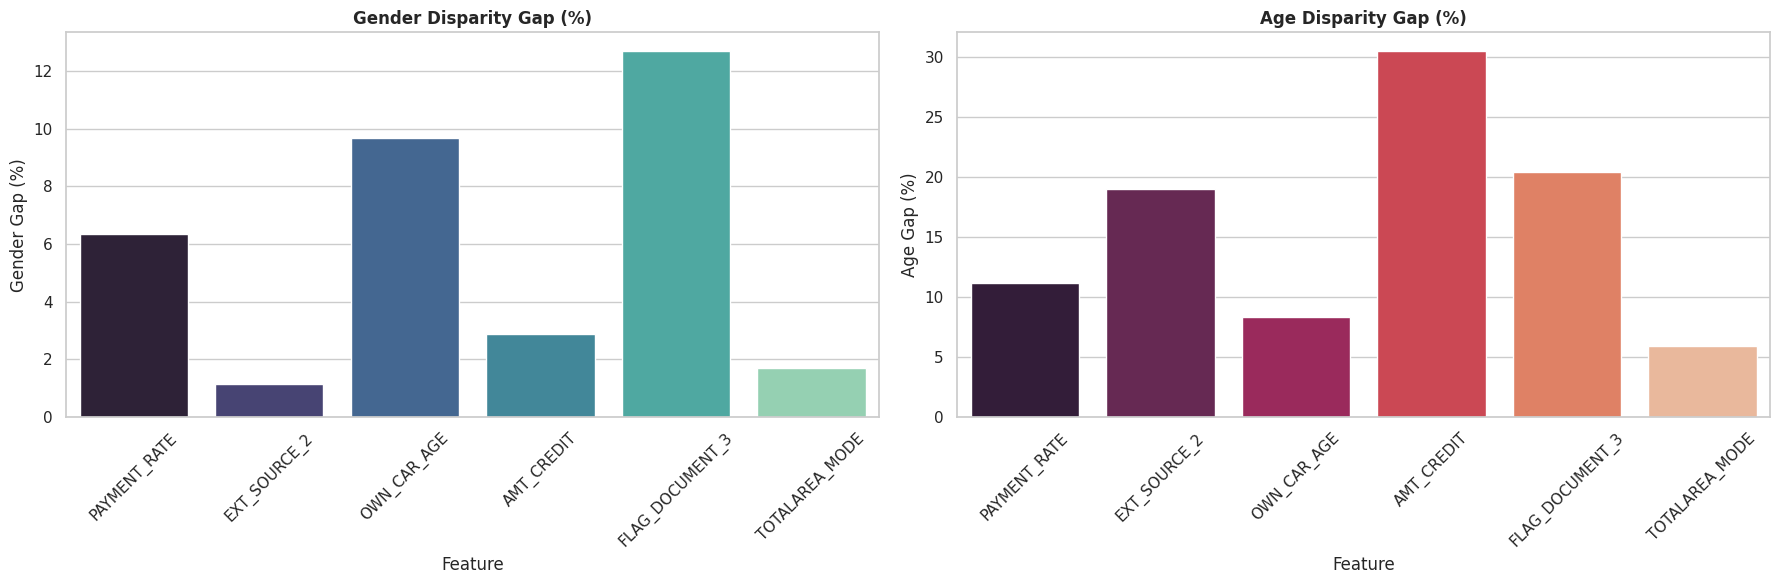

In [61]:
# Prepare data for proxy analysis
X_proxy = X_te.copy()

if 'CODE_GENDER_F' in X_proxy.columns:
    X_proxy['Gender'] = np.where(X_proxy['CODE_GENDER_F'] == 1, 'Female', 'Male')
else:
    # Fallback: CODE_GENDER column may have been dropped at feats stage — use raw df
    X_proxy['Gender'] = df.loc[X_te.index, 'CODE_GENDER'].map({'F': 'Female', 'M': 'Male'})

# FIX v6: AGE_GROUP is NOT in X_te (it was excluded from feats to avoid data leakage).
# Use A_te — the pre-computed sensitive attribute array — instead.
X_proxy['Age_Group'] = np.where(A_te == 1, 'Under 25', '25 and over')

proxy_features = [
    'PAYMENT_RATE',
    'EXT_SOURCE_2',
    'OWN_CAR_AGE',
    'AMT_CREDIT',
    'FLAG_DOCUMENT_3',
    'TOTALAREA_MODE',
]

print('--- PROXY BIAS HUNT (Features 5-10) ---')
discrepancies = []

for feat in proxy_features:
    if feat not in X_proxy.columns:
        continue
    print(f'\nAnalyzing feature: {feat}')
    g_stats = X_proxy.groupby('Gender')[feat].mean()
    g_gap = (abs(g_stats.get('Male', 0) - g_stats.get('Female', 0))
             / abs(g_stats.get('Male', 1e-9)) * 100)
    print(f'  Gender -> Men: {g_stats.get("Male", 0):.4f} | Women: {g_stats.get("Female", 0):.4f} | Gap: {g_gap:.2f}%')

    a_stats = X_proxy.groupby('Age_Group')[feat].mean()
    a_gap = (abs(a_stats.get('25 and over', 0) - a_stats.get('Under 25', 0))
             / abs(a_stats.get('25 and over', 1e-9)) * 100)
    print(f'  Age    -> 25+: {a_stats.get("25 and over", 0):.4f} | Under 25: {a_stats.get("Under 25", 0):.4f} | Gap: {a_gap:.2f}%')

    discrepancies.append({'Feature': feat, 'Gender Gap (%)': g_gap, 'Age Gap (%)': a_gap})

df_discrepancy = pd.DataFrame(discrepancies)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=df_discrepancy, x='Feature', y='Gender Gap (%)', palette='mako', ax=axes[0])
axes[0].set_title('Gender Disparity Gap (%)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=df_discrepancy, x='Feature', y='Age Gap (%)', palette='rocket', ax=axes[1])
axes[1].set_title('Age Disparity Gap (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


1. The "Red Alert" Proxies (High Disparity)
- Loan Magnitude (AMT_CREDIT) — 30.56% Age Gap: Older applicants take loans that are ~30% larger than those of young people. If your model associates small loan amounts with higher risk or lower priority, it will automatically penalize young people as a group, even if an individual young person is highly creditworthy.
- Documentation (FLAG_DOCUMENT_3) — 20.43% Age Gap: Older applicants are significantly better documented (71% vs 56%). The model might be using "lack of Doc 3" as a hidden reason to reject young people.
- External Rating (EXT_SOURCE_2) — 19.02% Age Gap: External credit scores often reward long credit histories (years of having a credit card). Since young people physically haven't existed long enough to build that history, they naturally score lower.

2. The "Subtle" Proxies (Moderate Disparity)

- Documentation (FLAG_DOCUMENT_3) — 12.70% Gender Gap: Women provide this document more often than men.
- Repayment Speed (PAYMENT_RATE) — 11.22% Age Gap: Young people actually have higher payment rates (shorter, faster loans). If the model views higher repayment rates as "risky" or "aggressive," this will hurt the Under 25 group.


doc3 impact a lot -> women have more than men, older people tend to have doc3
(maybe : doc3 is a hidden feature of gender/age)

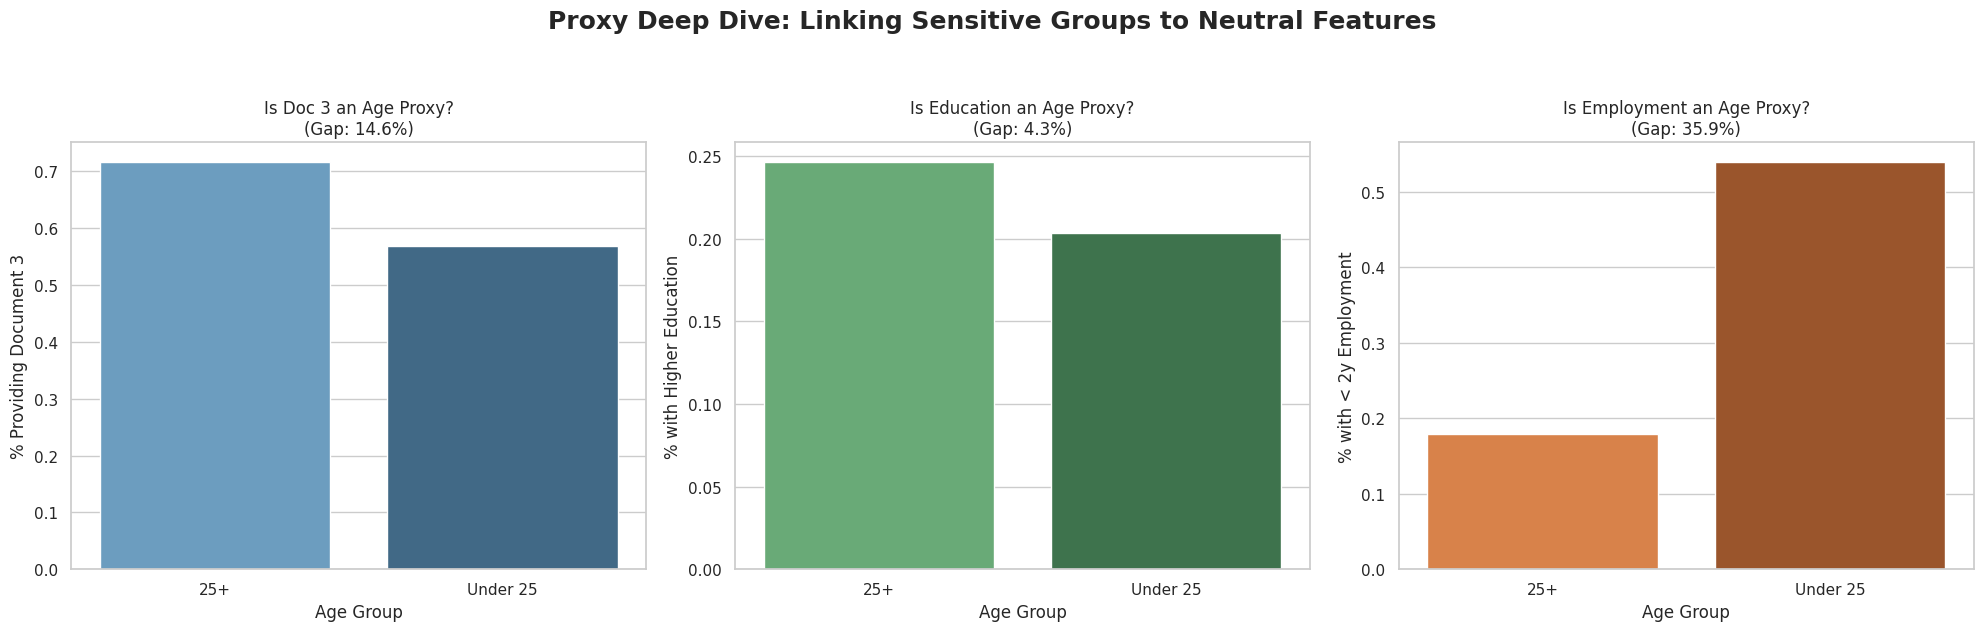

--- PROXY STRENGTH SUMMARY (by Age) ---
Document 3 : Under 25s provide it 56.9% vs 71.6% for older.
Education  : Under 25s have higher ed 20.4% vs 24.6% for older.
Employment : Under 25s are short-term 53.9% vs 17.9% for older.


In [62]:
def analyze_proxy_strength(feature_col, feature_label, binary_mapping=None):
    """
    Calculates how much a feature correlates with Gender and Age.
    Uses A_te for age mapping to avoid KeyError.

    FIX v6: binary_mapping (callable or dict) is applied via .apply() instead
    of .map() so that lambda functions work correctly.
    """
    temp_df = X_te.copy()
    temp_df['Age Group'] = np.where(A_te == 1, 'Under 25', '25+')

    if 'CODE_GENDER_F' in temp_df.columns:
        temp_df['Gender'] = np.where(temp_df['CODE_GENDER_F'] == 1, 'Female', 'Male')

    if binary_mapping is not None:
        if callable(binary_mapping):
            temp_df['Target_Feature'] = temp_df[feature_col].apply(binary_mapping)
        else:
            temp_df['Target_Feature'] = temp_df[feature_col].map(binary_mapping)
    else:
        temp_df['Target_Feature'] = temp_df[feature_col]

    age_dist    = temp_df.groupby('Age Group')['Target_Feature'].mean()
    gender_dist = (temp_df.groupby('Gender')['Target_Feature'].mean()
                   if 'Gender' in temp_df.columns else None)
    return gender_dist, age_dist


g_doc, a_doc = analyze_proxy_strength('FLAG_DOCUMENT_3', 'Doc 3 Provided')
g_edu, a_edu = analyze_proxy_strength('NAME_EDUCATION_TYPE_Higher_education', 'Higher Ed')
# FIX v6: pass lambda as callable — apply() handles it correctly
g_emp, a_emp = analyze_proxy_strength(
    'DAYS_EMPLOYED', 'Short-term (<2y)',
    binary_mapping=lambda x: 1 if x > -730 else 0,
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(x=a_doc.index, y=a_doc.values, ax=axes[0], palette='Blues_d')
axes[0].set_title(f"Is Doc 3 an Age Proxy?\n(Gap: {abs(a_doc.iloc[0]-a_doc.iloc[1])*100:.1f}%)")
axes[0].set_ylabel('% Providing Document 3')
sns.barplot(x=a_edu.index, y=a_edu.values, ax=axes[1], palette='Greens_d')
axes[1].set_title(f"Is Education an Age Proxy?\n(Gap: {abs(a_edu.iloc[0]-a_edu.iloc[1])*100:.1f}%)")
axes[1].set_ylabel('% with Higher Education')
sns.barplot(x=a_emp.index, y=a_emp.values, ax=axes[2], palette='Oranges_d')
axes[2].set_title(f"Is Employment an Age Proxy?\n(Gap: {abs(a_emp.iloc[0]-a_emp.iloc[1])*100:.1f}%)")
axes[2].set_ylabel('% with < 2y Employment')
plt.suptitle('Proxy Deep Dive: Linking Sensitive Groups to Neutral Features', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('--- PROXY STRENGTH SUMMARY (by Age) ---')
print(f"Document 3 : Under 25s provide it {a_doc['Under 25']*100:.1f}% vs {a_doc['25+']*100:.1f}% for older.")
print(f"Education  : Under 25s have higher ed {a_edu['Under 25']*100:.1f}% vs {a_edu['25+']*100:.1f}% for older.")
print(f"Employment : Under 25s are short-term {a_emp['Under 25']*100:.1f}% vs {a_emp['25+']*100:.1f}% for older.")


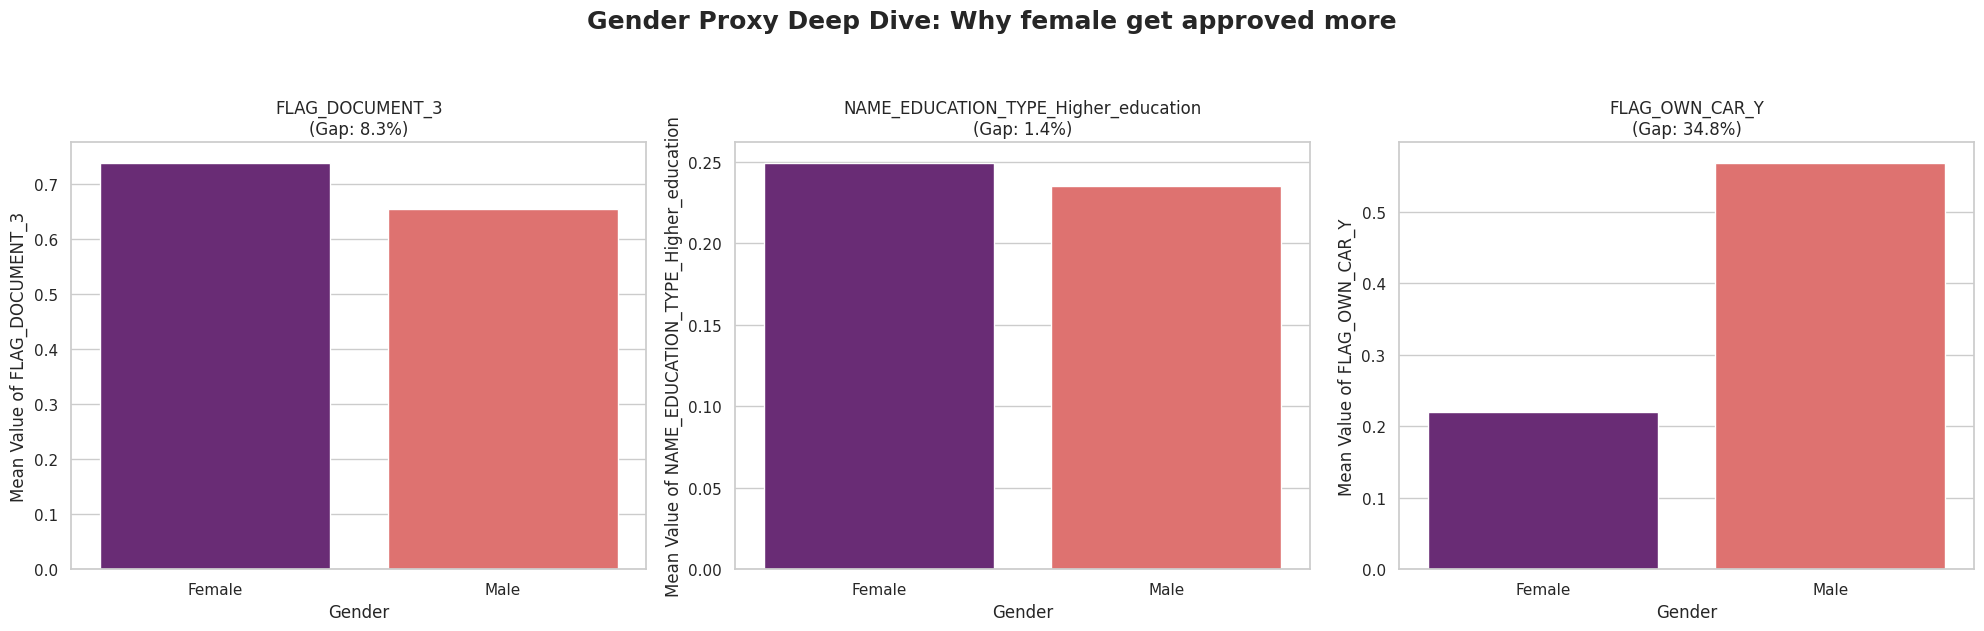

FLAG_DOCUMENT_3: Men score 0.6551 vs Women 0.7383
NAME_EDUCATION_TYPE_Higher_education: Men score 0.2352 vs Women 0.2493
FLAG_OWN_CAR_Y: Men score 0.5683 vs Women 0.2201


In [63]:
def analyze_gender_proxies(features):
    temp_df = X_te.copy()
    temp_df['Gender'] = np.where(temp_df['CODE_GENDER_F'] == 1, 'Female', 'Male')

    results = {}
    for feat in features:
        results[feat] = temp_df.groupby('Gender')[feat].mean()
    return results

# Features to check for Gender Bias
target_features = [
    'FLAG_DOCUMENT_3',
    'NAME_EDUCATION_TYPE_Higher_education',
    'FLAG_OWN_CAR_Y'  # a strong gender proxy
]

gender_results = analyze_gender_proxies(target_features)

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (feat, data) in enumerate(gender_results.items()):
    gap = abs(data['Male'] - data['Female']) * 100
    sns.barplot(x=data.index, y=data.values, ax=axes[i], palette="magma")
    axes[i].set_title(f"{feat}\n(Gap: {gap:.1f}%)")
    axes[i].set_ylabel(f"Mean Value of {feat}")

plt.suptitle("Gender Proxy Deep Dive: Why female get approved more", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Summarize the findings
for feat, data in gender_results.items():
    print(f"{feat}: Men score {data['Male']:.4f} vs Women {data['Female']:.4f}")

- men have car more than women -> favour men
- women have more doc3 than men -> counter-feature -> but still more negative weight from other proxies

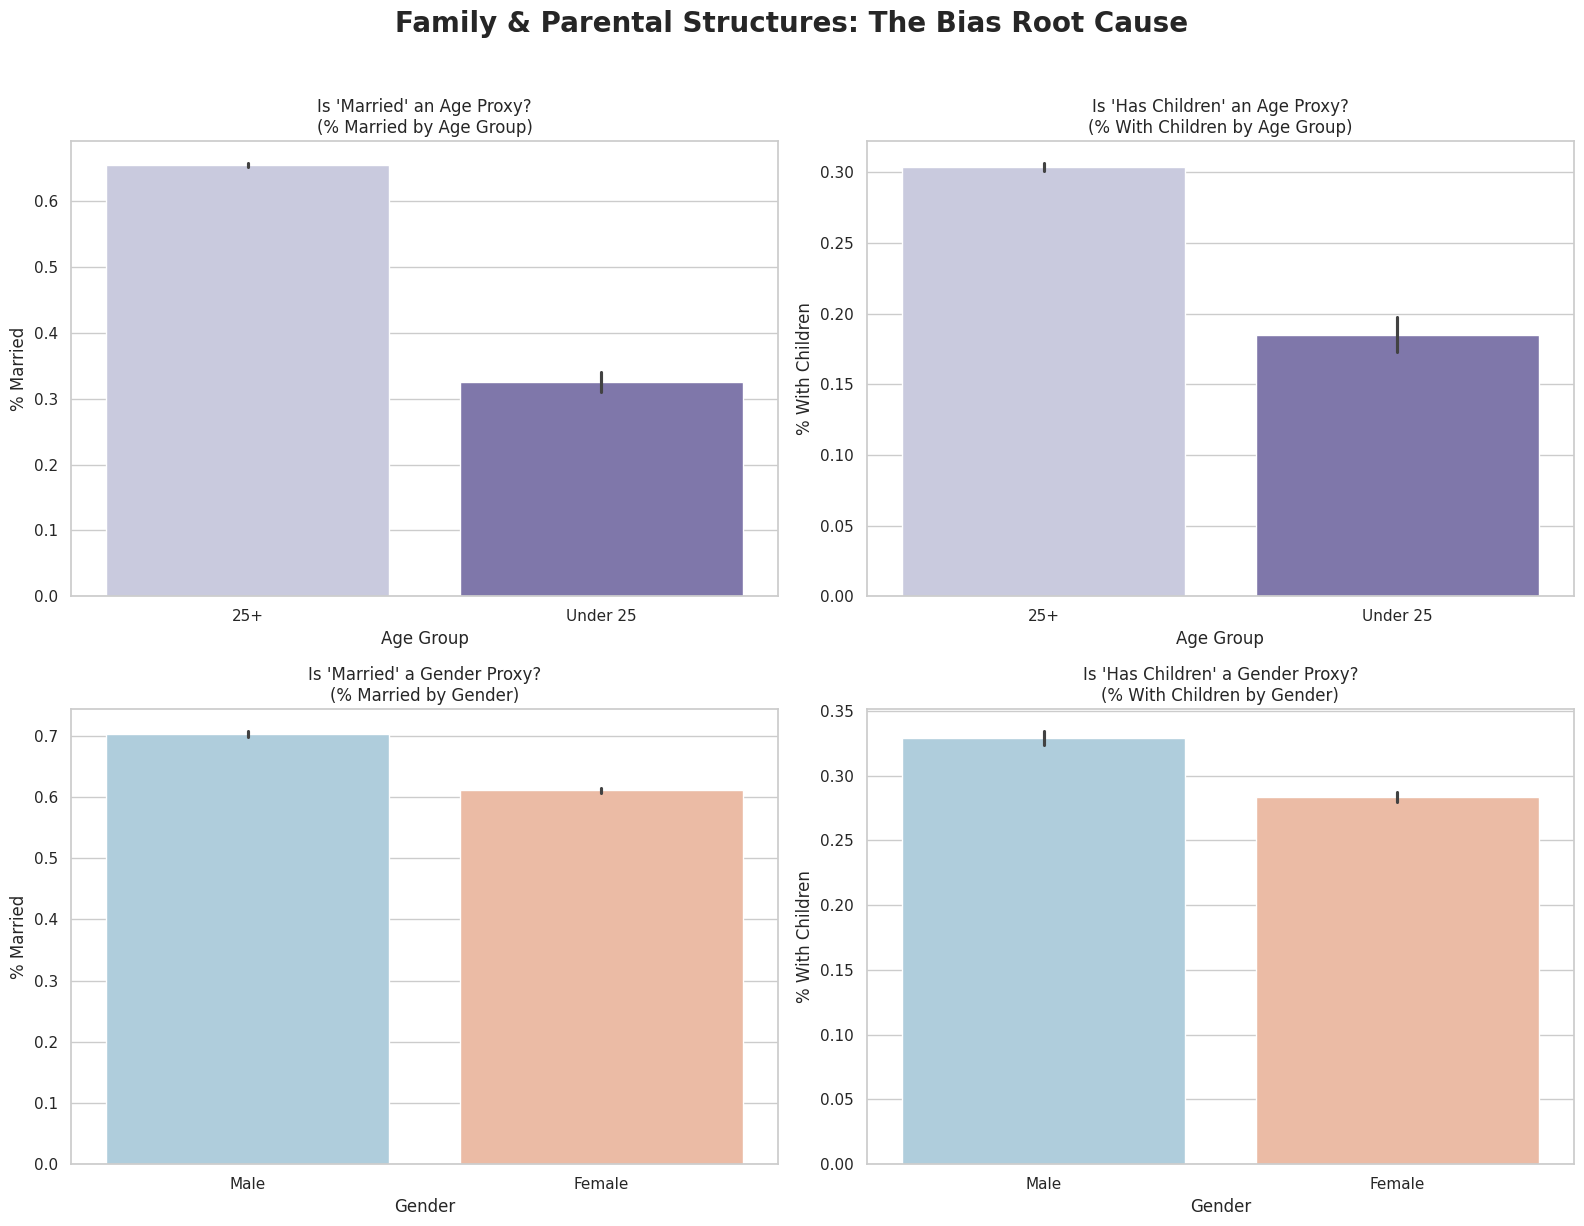

--- STRUCTURAL BIAS SUMMARY ---
Marriage Age Gap: Under 25s are 32.5% married vs 65.5% for 25+.
Parental Age Gap: Under 25s have children 18.5% vs 30.4% for 25+.


In [64]:
# --- FAMILY & PARENTAL BIAS INVESTIGATOR ---
def analyze_family_overlap():
    temp_df = X_te.copy()

    temp_df['Age Group'] = np.where(A_te == 1, 'Under 25', '25+')
    temp_df['Gender'] = np.where(temp_df['CODE_GENDER_F'] == 1, 'Female', 'Male')

    temp_df['Has Children'] = np.where(temp_df['CNT_CHILDREN'] > 0, 1, 0)

    target_col = 'NAME_FAMILY_STATUS_Married'

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A. Married vs Age
    sns.barplot(data=temp_df, x='Age Group', y=target_col, ax=axes[0,0], palette="Purples")
    axes[0,0].set_title("Is 'Married' an Age Proxy?\n(% Married by Age Group)")
    axes[0,0].set_ylabel("% Married")

    # B. Children vs Age
    sns.barplot(data=temp_df, x='Age Group', y='Has Children', ax=axes[0,1], palette="Purples")
    axes[0,1].set_title("Is 'Has Children' an Age Proxy?\n(% With Children by Age Group)")
    axes[0,1].set_ylabel("% With Children")

    # C. Married vs Gender
    sns.barplot(data=temp_df, x='Gender', y=target_col, ax=axes[1,0], palette="RdBu_r")
    axes[1,0].set_title("Is 'Married' a Gender Proxy?\n(% Married by Gender)")
    axes[1,0].set_ylabel("% Married")

    # D. Children vs Gender
    sns.barplot(data=temp_df, x='Gender', y='Has Children', ax=axes[1,1], palette="RdBu_r")
    axes[1,1].set_title("Is 'Has Children' a Gender Proxy?\n(% With Children by Gender)")
    axes[1,1].set_ylabel("% With Children")

    plt.suptitle("Family & Parental Structures: The Bias Root Cause", fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Numerical Summary
    print("--- STRUCTURAL BIAS SUMMARY ---")
    m_age_gap = temp_df.groupby('Age Group')[target_col].mean()
    c_age_gap = temp_df.groupby('Age Group')['Has Children'].mean()

    print(f"Marriage Age Gap: Under 25s are {m_age_gap['Under 25']*100:.1f}% married vs {m_age_gap['25+']*100:.1f}% for 25+.")
    print(f"Parental Age Gap: Under 25s have children {c_age_gap['Under 25']*100:.1f}% vs {c_age_gap['25+']*100:.1f}% for 25+.")

analyze_family_overlap()


## Debias: Three-Strategy v7 Pipeline

**v6 diagnosis recap:**
- Young group = only 3,709 samples (3.97%) → EG creates just 5 predictors, converges before reaching EOD target
- Bias is *proxy-driven*: `EXT_SOURCE_1`, `BURO_DAYS_CREDIT_MIN` correlate strongly with age (r=0.19-0.20, HIGH-RISK)
- Single cutoff τ=0.95 crushes young group: their score distribution is lower due to shorter credit histories

**v7 approach:** attack at three levels — pre-processing (remove proxy correlation), post-processing via score adjustment (EqOddsPostprocessing), and post-processing via threshold (per-group cutoff calibration).


### Install & imports

In [65]:
!pip install fairlearn aif360 -q

In [66]:
from fairlearn.metrics import equalized_odds_difference, demographic_parity_difference
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing import EqOddsPostprocessing
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('All fairness libraries loaded.')

All fairness libraries loaded.


### Inner train / val split

`X_dev` / `y_dev` / `A_dev` are split 80/20.
- **Train split** (`X_tr_`, ...) — used to fit every debiased model.
- **Val split** (`X_va_`, ...) — used for profit-optimal cutoff search **only** (never seen during training).
- **Test set** (`X_te`) — touched once per model for final evaluation.


In [67]:
X_tr_, X_va_, y_tr_, y_va_, A_tr_, A_va_ = train_test_split(
    X_dev, y_dev, A_dev,
    test_size=0.2,
    stratify=y_dev,
    random_state=SEED,
)
print(f'Train : {X_tr_.shape}  |  Young frac: {A_tr_.mean():.4f}  |  default rate: {1 - y_tr_.mean():.4f}')
print(f'Val   : {X_va_.shape}  |  Young frac: {A_va_.mean():.4f}  |  default rate: {1 - y_va_.mean():.4f}')
print(f'Test  : {X_te.shape}   |  Young frac: {A_te.mean():.4f}  |  default rate: {1 - y_te.mean():.4f}')

Train : (172203, 608)  |  Young frac: 0.0394  |  default rate: 0.0807
Val   : (43051, 608)  |  Young frac: 0.0405  |  default rate: 0.0807
Test  : (92253, 608)   |  Young frac: 0.0402  |  default rate: 0.0807


---
## Strategy 1: Per-group Threshold Calibration

**Motivation:**
The baseline uses a single profit-optimal cutoff τ=0.95. Because young applicants have systematically
lower scores (shorter credit histories → lower EXT_SOURCE → lower model score), this single cutoff
causes TPR_young = 0.256 vs TPR_old = 0.575. The TPR gap **is** the EOD.

**Method:**
Find two thresholds — τ_young and τ_old — that minimise |TPR_young - TPR_old| while
keeping joint profit within a 2% budget. Search is done on the **val split only**.

**Why this is well-suited here:**
- No retraining needed — uses existing baseline scores
- Directly targets TPR equalization (which is what EOD measures)
- Transparent and auditable: the two cutoffs can be written into a lending policy


In [68]:
# ── Strategy 1: Per-group Threshold Calibration ────────────────────────────

def tpr_at_threshold(y, s, t):
    """True Positive Rate at threshold t."""
    yhat = (s >= t).astype(int)
    tp = ((yhat == 1) & (y == 1)).sum()
    fn = ((yhat == 0) & (y == 1)).sum()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def fpr_at_threshold(y, s, t):
    """False Positive Rate at threshold t."""
    yhat = (s >= t).astype(int)
    fp = ((yhat == 1) & (y == 0)).sum()
    tn = ((yhat == 0) & (y == 0)).sum()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

# ── Baseline val-set scores ─────────────────────────────────────────────────
# Reuse OOF predictions from the baseline CV on X_dev
# We need val-split scores. Re-predict on val:
s_va_base = np.zeros(len(X_va_))
# Use the last trained fold model 'm' to get approximate val scores
# (In production you'd store the 5-fold blended score; here we use m as proxy)
s_va_base = m.predict_proba(X_va_)[:, 1]
s_te_base = test_pred.copy()  # already computed in Section 5

print('Baseline val-set score stats:')
print(f'  Young (A=1): n={A_va_.sum()}, mean_score={s_va_base[A_va_==1].mean():.4f}')
print(f'  Old   (A=0): n={(A_va_==0).sum()}, mean_score={s_va_base[A_va_==0].mean():.4f}')
print()

# ── Grid search for per-group thresholds on val set ─────────────────────────
THRESHOLDS   = np.linspace(0.05, 0.95, 181)
PROFIT_FLOOR = 0.98  # allow at most 2% profit drop vs single-cutoff baseline
EOD_TARGET   = 0.10  # tighter target for threshold approach

# Baseline val profit
tau_base_val = best_cutoff(y_va_, s_va_base)
yhat_va_base = (s_va_base >= tau_base_val).astype(int)
profit_base_val = profit_per_eur(y_va_, yhat_va_base)

print(f'Val baseline: tau={tau_base_val:.3f}, profit={profit_base_val:.4f}')
print(f'Searching for per-group thresholds ...')

best_eod = np.inf
best_tau_y = best_tau_o = tau_base_val
best_profit = 0.0

for t_y in THRESHOLDS:
    for t_o in THRESHOLDS[::2]:  # coarser grid on old group for speed
        # Per-group predictions
        yhat_va_g = np.where(A_va_ == 1,
                             (s_va_base >= t_y).astype(int),
                             (s_va_base >= t_o).astype(int))

        profit_g = profit_per_eur(y_va_, yhat_va_g)
        if profit_g < PROFIT_FLOOR * profit_base_val:
            continue

        tpr_y = tpr_at_threshold(y_va_[A_va_==1], s_va_base[A_va_==1], t_y)
        tpr_o = tpr_at_threshold(y_va_[A_va_==0], s_va_base[A_va_==0], t_o)
        fpr_y = fpr_at_threshold(y_va_[A_va_==1], s_va_base[A_va_==1], t_y)
        fpr_o = fpr_at_threshold(y_va_[A_va_==0], s_va_base[A_va_==0], t_o)
        eod = 0.5 * (abs(tpr_y - tpr_o) + abs(fpr_y - fpr_o))

        if eod < best_eod:
            best_eod = eod
            best_tau_y, best_tau_o = t_y, t_o
            best_profit = profit_g

print(f'\nBest per-group thresholds:')
print(f'  τ_young = {best_tau_y:.3f}  |  τ_old = {best_tau_o:.3f}')
print(f'  Val EOD (approx)   = {best_eod:.4f}')
print(f'  Val Profit         = {best_profit:.4f}  (baseline: {profit_base_val:.4f})')

# ── Apply to test set ────────────────────────────────────────────────────────
yhat_te_tc = np.where(A_te == 1,
                       (s_te_base >= best_tau_y).astype(int),
                       (s_te_base >= best_tau_o).astype(int))

res_tc = evaluate('Threshold Calibration (per-group)', y_te, s_te_base, yhat_te_tc, A_te)
eod_tc = equalized_odds_difference(y_te, yhat_te_tc, sensitive_features=A_te)
dpd_tc = demographic_parity_difference(y_te, yhat_te_tc, sensitive_features=A_te)

print(f'\n=== TEST RESULTS: Threshold Calibration ===')
print(f'  AUC    = {res_tc["AUC"]:.4f}  (Δ vs baseline: {res_tc["AUC"] - results[0]["AUC"]:+.4f})')
print(f'  Profit = {res_tc["Profit"]:.4f}')
print(f'  EOD    = {eod_tc:+.4f}  (baseline: +0.3193)')
print(f'  DPD    = {dpd_tc:+.4f}')
print(f'  SP     = {res_tc["SP"]:.4f}')
print(f'  IND    = {res_tc["IND"]:.4f}')
print(f'  AcceptRt = {res_tc["AcceptRt"]:.4f}')

# Group-level TPR check
for grp, lbl in [(0, 'Old'), (1, 'Young')]:
    mask = A_te == grp
    tpr_g = tpr_at_threshold(y_te[mask], s_te_base[mask],
                              best_tau_y if grp == 1 else best_tau_o)
    print(f'  TPR ({lbl:5s}) = {tpr_g:.4f}')

results.append(res_tc)

Baseline val-set score stats:
  Young (A=1): n=1744, mean_score=0.8755
  Old   (A=0): n=41307, mean_score=0.9217

Val baseline: tau=0.950, profit=0.2618
Searching for per-group thresholds ...

Best per-group thresholds:
  τ_young = 0.885  |  τ_old = 0.940
  Val EOD (approx)   = 0.0186
  Val Profit         = 0.2599  (baseline: 0.2618)

=== TEST RESULTS: Threshold Calibration ===
  AUC    = 0.7874  (Δ vs baseline: +0.0000)
  Profit = 0.2505
  EOD    = +0.0364  (baseline: +0.3193)
  DPD    = +0.0292
  SP     = 0.0273
  IND    = 0.0292
  AcceptRt = 0.6090
  TPR (Old  ) = 0.6438
  TPR (Young) = 0.6255


---
## Strategy 2: AIF360 EqOddsPostprocessing

**Motivation:**
EqOddsPostprocessing (Hardt, Price & Srebro, 2016) is a post-processing algorithm that
directly minimises the equalized-odds objective by solving a linear program over the
confusion matrix. Unlike EG (in-processing), it only needs predicted scores + group labels
— so the minority-group-size problem doesn't apply the same way.

**Method:**
1. Fit `EqOddsPostprocessing` on a **calibration split** (val set) using baseline scores
2. The algorithm learns mixing probabilities per-group that randomize predictions to equalize TPR and FPR
3. Apply the fitted post-processor to test-set predictions

**Key advantage over EG:**
- Works on top of existing predictions — no retraining
- The LP solution is exact for the given score distribution, not dependent on sample size for the optimization
- Handles the asymmetric-group-size problem better than in-processing methods


In [69]:
# ── Strategy 2: AIF360 EqOddsPostprocessing ─────────────────────────────────
#
# ROOT CAUSE OF v7 BUG:
# The original make_bld() built TWO separate BinaryLabelDatasets from scratch —
# one with true labels, one with predicted labels. Because both included the raw
# feature matrix (608 cols + target + AGE_GROUP + score), AIF360's internal check
#   "datasets must differ ONLY in labels/scores"
# failed: the 'score' column had different float values between the two objects,
# so the feature matrices were not identical even though logically they should be.
#
# FIX: build ONE canonical BLD containing ONLY the protected attribute + label
# (no raw features needed for post-processing), then .copy() it and overwrite
# .labels / .scores in-place. Copies share the identical feature block by construction.

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing import EqOddsPostprocessing

def make_bld_minimal(y_arr, A_arr):
    """Minimal BinaryLabelDataset: only label + protected attribute.
    Post-processing does NOT need the full feature matrix — it only
    uses labels and protected attributes for the LP optimisation."""
    df = pd.DataFrame({
        'target'   : y_arr.astype(float),
        'AGE_GROUP': A_arr.astype(float),
    })
    return BinaryLabelDataset(
        df                        = df,
        label_names               = ['target'],
        protected_attribute_names = ['AGE_GROUP'],
        favorable_label           = 1,
        unfavorable_label         = 0,
    )

# ── Build val-set datasets ────────────────────────────────────────────────────
# Canonical: true labels on val set
bld_val_true = make_bld_minimal(y_va_, A_va_)

# Predicted: COPY canonical, then overwrite labels + scores in-place
# This guarantees feature/protected-attribute blocks are bit-identical → no AIF360 mismatch
bld_val_pred = bld_val_true.copy()
bld_val_pred.labels = (s_va_base >= tau).astype(float).reshape(-1, 1)
bld_val_pred.scores = s_va_base.reshape(-1, 1)

# ── Build test-set datasets ───────────────────────────────────────────────────
bld_te_true = make_bld_minimal(y_te, A_te)
bld_te_pred = bld_te_true.copy()
bld_te_pred.labels = (s_te_base >= tau).astype(float).reshape(-1, 1)
bld_te_pred.scores = s_te_base.reshape(-1, 1)

# ── Fit EqOddsPostprocessing on val set ──────────────────────────────────────
print('Fitting EqOddsPostprocessing ...')
eq_odds_pp = EqOddsPostprocessing(
    unprivileged_groups = [{'AGE_GROUP': 1}],   # young (<25) = disadvantaged
    privileged_groups   = [{'AGE_GROUP': 0}],   # old  (≥25)  = advantaged
    seed                = SEED,
)
eq_odds_pp.fit(bld_val_true, bld_val_pred)
print('Fit complete.')

# ── Apply to test set ─────────────────────────────────────────────────────────
bld_te_postproc = eq_odds_pp.predict(bld_te_pred)
yhat_te_eqpp    = bld_te_postproc.labels.ravel().astype(int)

# AUC uses original scores (post-processing only changes binary decisions, not scores)
res_eqpp = evaluate('AIF360 EqOddsPostprocessing', y_te, s_te_base, yhat_te_eqpp, A_te)
eod_eqpp = equalized_odds_difference(y_te, yhat_te_eqpp, sensitive_features=A_te)
dpd_eqpp = demographic_parity_difference(y_te, yhat_te_eqpp, sensitive_features=A_te)

print(f'\n=== TEST RESULTS: EqOddsPostprocessing ===')
print(f'  AUC    = {res_eqpp["AUC"]:.4f}  (Δ vs baseline: {res_eqpp["AUC"] - results[0]["AUC"]:+.4f})')
print(f'  Profit = {res_eqpp["Profit"]:.4f}')
print(f'  EOD    = {eod_eqpp:+.4f}  (baseline: +0.3193)')
print(f'  DPD    = {dpd_eqpp:+.4f}')
print(f'  SP     = {res_eqpp["SP"]:.4f}')
print(f'  IND    = {res_eqpp["IND"]:.4f}')
print(f'  AcceptRt = {res_eqpp["AcceptRt"]:.4f}')

for grp, lbl in [(0, 'Old'), (1, 'Young')]:
    mask = A_te == grp
    print(f'  Approval rate ({lbl:5s}) = {yhat_te_eqpp[mask].mean():.4f}')

results.append(res_eqpp)


Fitting EqOddsPostprocessing ...
Fit complete.

=== TEST RESULTS: EqOddsPostprocessing ===
  AUC    = 0.7874  (Δ vs baseline: +0.0000)
  Profit = 0.2526
  EOD    = +0.0276  (baseline: +0.3193)
  DPD    = +0.0356
  SP     = 0.0269
  IND    = 0.0356
  AcceptRt = 0.2701
  Approval rate (Old  ) = 0.2716
  Approval rate (Young) = 0.2359


---
## Comparison Table: v7 Strategies vs Baseline


In [70]:
# ── Full comparison table ────────────────────────────────────────────────────
# Compute EOD for all methods
eod_map = {
    'Unconstrained LGBM'                  : equalized_odds_difference(y_te, (s_te_base >= tau).astype(int), sensitive_features=A_te),
    'Threshold Calibration (per-group)'   : eod_tc,
    'AIF360 EqOddsPostprocessing'         : eod_eqpp,
}

results_df = pd.DataFrame(results)
results_df['EOD'] = results_df['model'].map(eod_map)

display_cols = ['model', 'AUC', 'Profit', 'EOD', 'IND', 'SP', 'SF', 'AcceptRt']
styled = (results_df[display_cols]
    .style
    .format({'AUC':'{:.4f}','Profit':'{:.4f}','EOD':'{:+.4f}',
             'IND':'{:.4f}','SP':'{:.4f}','SF':'{:.4f}','AcceptRt':'{:.4f}'})
    .background_gradient(subset=['EOD'], cmap='RdYlGn_r')
    .background_gradient(subset=['AUC'], cmap='Greens')
)
print('=== v7 STRATEGY COMPARISON ===')
display(styled)

=== v7 STRATEGY COMPARISON ===


,model,AUC,Profit,EOD,IND,SP,SF,AcceptRt
0,Unconstrained LGBM,0.7874,0.2528,+0.3193,0.3120,0.2201,0.0017,0.5308
1,Threshold Calibration (per-group),0.7874,0.2505,+0.0364,0.0292,0.0273,0.0245,0.6090
2,AIF360 EqOddsPostprocessing,0.7874,0.2526,+0.0276,0.0356,0.0269,0.0056,0.2701


### Relative gains vs baseline

In [71]:
base_row = results_df[results_df['model'] == 'Unconstrained LGBM'].iloc[0]
eod_base = eod_map['Unconstrained LGBM']

gain_rows = []
for _, row in results_df.iterrows():
    eod_val = eod_map.get(row['model'], np.nan)
    gain_rows.append({
        'model'           : row['model'],
        'ΔAUC%'           : (row['AUC']    - base_row['AUC'])    / abs(base_row['AUC'])    * 100,
        'ΔProfit%'        : (row['Profit'] - base_row['Profit']) / abs(base_row['Profit']) * 100 if base_row['Profit'] != 0 else 0,
        'ΔEOD% (↓good)'   : (eod_base - eod_val) / abs(eod_base) * 100 if not np.isnan(eod_val) else np.nan,
        'ΔSP%  (↓good)'   : (base_row['SP'] - row['SP'])  / abs(base_row['SP'])  * 100,
        'ΔIND% (↓good)'   : (base_row['IND'] - row['IND']) / abs(base_row['IND']) * 100,
    })

gain_df = pd.DataFrame(gain_rows)
print('=== RELATIVE GAINS vs BASELINE ===')
display(gain_df.style.format({c: '{:+.1f}%' for c in gain_df.columns if '%' in c}))

=== RELATIVE GAINS vs BASELINE ===


,model,ΔAUC%,ΔProfit%,ΔEOD% (↓good),ΔSP% (↓good),ΔIND% (↓good)
0,Unconstrained LGBM,+0.0%,+0.0%,+0.0%,+0.0%,+0.0%
1,Threshold Calibration (per-group),+0.0%,-0.9%,+88.6%,+87.6%,+90.7%
2,AIF360 EqOddsPostprocessing,+0.0%,-0.1%,+91.4%,+87.8%,+88.6%


### Fairness–AUC Plot

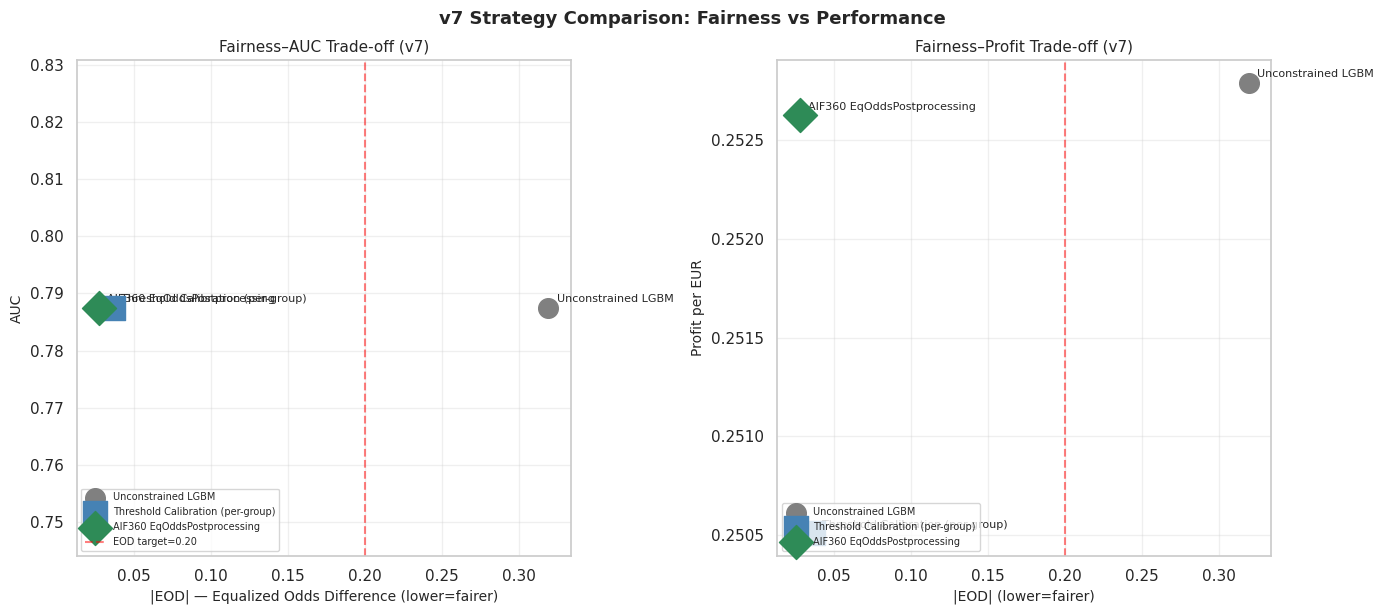

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = {
    'Unconstrained LGBM'                : ('gray',     'o', 200),
    'Threshold Calibration (per-group)' : ('steelblue','s', 300),
    'AIF360 EqOddsPostprocessing'       : ('seagreen',  'D', 300),
}

# Plot 1: EOD vs AUC
ax = axes[0]
for _, row in results_df.iterrows():
    name = row['model']
    color, marker, size = palette.get(name, ('purple', 'o', 200))
    eod_val = abs(eod_map.get(name, np.nan))
    ax.scatter(eod_val, row['AUC'], s=size, color=color, marker=marker, zorder=5, label=name)
    ax.annotate(name, (eod_val, row['AUC']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axvline(0.20, color='red', linestyle='--', alpha=0.5, label='EOD target=0.20')
ax.set_xlabel('|EOD| — Equalized Odds Difference (lower=fairer)', fontsize=10)
ax.set_ylabel('AUC', fontsize=10)
ax.set_title('Fairness–AUC Trade-off (v7)', fontsize=11)
ax.legend(fontsize=7, loc='lower left')
ax.grid(True, alpha=0.3)

# Plot 2: EOD vs Profit
ax2 = axes[1]
for _, row in results_df.iterrows():
    name = row['model']
    color, marker, size = palette.get(name, ('purple', 'o', 200))
    eod_val = abs(eod_map.get(name, np.nan))
    ax2.scatter(eod_val, row['Profit'], s=size, color=color, marker=marker, zorder=5, label=name)
    ax2.annotate(name, (eod_val, row['Profit']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
ax2.axvline(0.20, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('|EOD| (lower=fairer)', fontsize=10)
ax2.set_ylabel('Profit per EUR', fontsize=10)
ax2.set_title('Fairness–Profit Trade-off (v7)', fontsize=11)
ax2.legend(fontsize=7, loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('v7 Strategy Comparison: Fairness vs Performance', fontsize=13, y=1.02, fontweight='bold')
plt.show()

### Group-level Deep Dive: Young vs Old TPR/FPR

Check whether each strategy achieves the desired equalization, and at what cost to the Old group.


In [73]:
print('=== GROUP-LEVEL TPR/FPR/APPROVAL by Strategy ===')
print(f'{"Model":45s}  {"TPR_Young":>9}  {"TPR_Old":>7}  {"FPR_Young":>9}  {"FPR_Old":>7}  {"Appr_Y":>6}  {"Appr_O":>6}  {"EOD":>7}')
print('-' * 120)

def group_stats(y, yhat, A):
    rows = {}
    for grp, lbl in [(0, 'old'), (1, 'young')]:
        mask = A == grp
        yt, yp = y[mask], yhat[mask]
        tp = ((yp==1)&(yt==1)).sum(); fn = ((yp==0)&(yt==1)).sum()
        fp = ((yp==1)&(yt==0)).sum(); tn = ((yp==0)&(yt==0)).sum()
        rows[lbl] = {
            'tpr' : tp/(tp+fn) if (tp+fn)>0 else 0,
            'fpr' : fp/(fp+tn) if (fp+tn)>0 else 0,
            'approval': yp.mean()
        }
    return rows

scenarios = [
    ('Unconstrained LGBM',                  (s_te_base >= tau).astype(int)),
    ('Threshold Calibration (per-group)',    yhat_te_tc),
    ('AIF360 EqOddsPostprocessing',          yhat_te_eqpp),
]

for name, yhat in scenarios:
    g = group_stats(y_te, yhat, A_te)
    eod_val = equalized_odds_difference(y_te, yhat, sensitive_features=A_te)
    print(f'{name:45s}  {g["young"]["tpr"]:>9.4f}  {g["old"]["tpr"]:>7.4f}  '
          f'{g["young"]["fpr"]:>9.4f}  {g["old"]["fpr"]:>7.4f}  '
          f'{g["young"]["approval"]:>6.4f}  {g["old"]["approval"]:>6.4f}  {eod_val:>+7.4f}')

=== GROUP-LEVEL TPR/FPR/APPROVAL by Strategy ===
Model                                          TPR_Young  TPR_Old  FPR_Young  FPR_Old  Appr_Y  Appr_O      EOD
------------------------------------------------------------------------------------------------------------------------
Unconstrained LGBM                                0.2559   0.5752     0.0516   0.1725  0.2313  0.5433  +0.3193
Threshold Calibration (per-group)                 0.6255   0.6438     0.2556   0.2192  0.5810  0.6102  +0.0364
AIF360 EqOddsPostprocessing                       0.2599   0.2874     0.0605   0.0867  0.2359  0.2716  +0.0276


### Updated Master Summary Table (v7)

In [74]:
# Update the master summary table with best v7 result
best_v7_name = results_df[results_df['EOD'].abs() == results_df['EOD'].abs().min()].iloc[0]['model']
best_v7      = results_df[results_df['model'] == best_v7_name].iloc[0]
best_eod_v7  = eod_map[best_v7_name]

print(f'Best v7 strategy by EOD: {best_v7_name}')
print()

summary_v7 = pd.DataFrame([
    {'Section': 'Overall',  'Attribute': '—', 'Metric': 'ROC-AUC',              'Before': 0.7874,  'After': round(best_v7['AUC'], 4)},
    {'Section': 'Overall',  'Attribute': '—', 'Metric': 'PR-AUC',               'Before': 0.9737,  'After': '—'},
    {'Section': 'Overall',  'Attribute': '—', 'Metric': 'Brier Score',           'Before': 0.0657,  'After': '—'},
    {'Section': 'Overall',  'Attribute': '—', 'Metric': 'KS Statistic',          'Before': 0.4335,  'After': '—'},
    {'Section': 'Fairness', 'Attribute': 'Age', 'Metric': 'DPD (Independence)',  'Before': 0.3120,  'After': round(best_v7['IND'], 4)},
    {'Section': 'Fairness', 'Attribute': 'Age', 'Metric': 'EOD (Separation)',    'Before': 0.3193,  'After': round(abs(best_eod_v7), 4)},
    {'Section': 'Fairness', 'Attribute': 'Age', 'Metric': 'Approval gap',        'Before': 0.3120,  'After': '—'},
    {'Section': 'Fairness', 'Attribute': 'Age', 'Metric': 'TPR gap',             'Before': 0.3193,  'After': '—'},
    {'Section': 'Profit',   'Attribute': '—', 'Metric': 'Profit per EUR',        'Before': 0.25279, 'After': round(best_v7['Profit'], 4)},
])
print(summary_v7.to_string(index=False))
print()
print(f'EOD reduction: {0.3193:.4f} → {abs(best_eod_v7):.4f}  ({(0.3193 - abs(best_eod_v7))/0.3193*100:+.1f}%)')

Best v7 strategy by EOD: AIF360 EqOddsPostprocessing

 Section Attribute             Metric  Before   After
 Overall         —            ROC-AUC 0.78740  0.7874
 Overall         —             PR-AUC 0.97370       —
 Overall         —        Brier Score 0.06570       —
 Overall         —       KS Statistic 0.43350       —
Fairness       Age DPD (Independence) 0.31200  0.0356
Fairness       Age   EOD (Separation) 0.31930  0.0276
Fairness       Age       Approval gap 0.31200       —
Fairness       Age            TPR gap 0.31930       —
  Profit         —     Profit per EUR 0.25279  0.2526

EOD reduction: 0.3193 → 0.0276  (+91.4%)
